# Assignment Module 2: Aircraft Classification

The goal of this assignment is to implement a neural network that classifies images of 100 aircraft model variants from the [Fine-Grained Visual Classification of Aircraft (**FGVC-Aircraft**) dataset](https://www.robots.ox.ac.uk/~vgg/data/fgvc-aircraft/). The assignment is divided into two parts: first, you will be asked to implement your own neural network for image classification from scratch; then, you will fine-tune a pretrained network provided by PyTorch.

![](https:///raw.githubusercontent.com/CVLAB-Unibo/ipcv-assignment-2/master/fgvc_aircraft_variants.svg)

## Dataset

Download and acces the dataset through its official [PyTorch `FGVCAircraft` class](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.FGVCAircraft.html) (by setting its constructor argument `annotation_level` to `'variant'`).

##### Imports + dataset

In [1]:
# set up
from dataclasses import dataclass
import json
import torch
import torch.nn.functional as F
from torch.nn import (
    AdaptiveAvgPool2d,
    BatchNorm2d,
    Conv2d,
    Dropout,
    Linear,
    MaxPool2d,
    Module,
    Parameter,
    ReLU,
    Sequential,
)
from  torchvision.datasets  import FGVCAircraft
from typing import Literal, Optional, Tuple, Union
import matplotlib.pyplot as plt
import math
from pathlib import Path
from PIL import Image
import time
from torch import nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR, OneCycleLR
from torchvision import transforms as T
from torch.optim import Adam, SGD

from torchvision.models import ResNet18_Weights, resnet18


DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)


cuda


## Part 1: design your own network

Your goal is to implement a convolutional neural network for image classification and train it from scratch on `FGVCAircraft`. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~50%. You are free to achieve this however you want, except for a few rules you must follow:

- Compile this notebook by displaying the results obtained by the best model you found throughout your experimentation; then show how, by removing some of its components, its performance drops. In other words, do an *ablation study* to prove that your design choices have a positive impact on the final result.

- Do not instantiate an off-the-self PyTorch network. Instead, construct your network as a composition of existing PyTorch layers. In more concrete terms, you can use e.g. `torch.nn.Linear`, but you cannot use e.g. `torchvision.models.alexnet`.

- Show your results and ablations with plots, tables, images, etc. — the clearer, the better.

Don't be too concerned with your model performance: the ~50% is just to give you an idea of when to stop. Keep in mind that a thoroughly justified model with lower accuracy will be rewarded more points than a poorly experimentally validated model with higher accuracy.

##### Network modules: stem layers downsampling -> CNN feature extractor (inception or resnet) -> FC classifier

In [2]:
def _as_hw(size):
    """Helper to map a side length L into the shape tuple (L, L)"""
    return (size, size) if isinstance(size, int) else tuple(size)


class Stem(Module):
    """Resizes the input to a canonical size, then downsamples with
    `conv -> batchnorm -> activation -> maxpool` blocks.

    With the default `canonical_size=256` and three stride-2 poolings,
    output is 256 / 2**3 = 32 pixels per side, at `channels[-1]` channels.
    """

    def __init__(
        self, in_channels=3, canonical_size=256, channels=(32, 64, 128), kernel_size=3
    ):
        super().__init__()
        self.canonical_size = _as_hw(canonical_size)

        kernel_padding = kernel_size // 2
        blocks = []
        prev_channels = in_channels
        for out_channels in channels:
            blocks += [
                Conv2d(
                    prev_channels, out_channels, kernel_size, padding=kernel_padding
                ),
                BatchNorm2d(out_channels),
                ReLU(inplace=True),
                MaxPool2d(2),
            ]
            prev_channels = out_channels
        self.blocks = Sequential(*blocks)

    def forward(self, x):
        x = F.interpolate(
            x, size=self.canonical_size, mode="bilinear", align_corners=False
        )
        return self.blocks(x)


class DropPath(Module):
    """Stochastic depth (Huang et al., 2016): during training, drops the
    entire residual branch for a random subset of samples in the batch,
    scaling survivors by `1 / (1 - drop_prob)` to preserve the expected
    branch magnitude. A no-op at eval time or when `drop_prob == 0.0`."""

    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0.0 or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        mask_shape = (x.shape[0],) + (1,) * (x.dim() - 1)
        mask = x.new_empty(mask_shape).bernoulli_(keep_prob)
        return x * mask / keep_prob


class ResidualStage(Module):
    """conv(stride) -> bn -> act -> conv(stride=1) -> bn, added to a 1x1-conv
    shortcut that reshapes the input to the output's shape, then activated."""

    def __init__(
        self, in_channels, out_channels, stride=2, kernel_size=3, stochastic_depth=0.0
    ):
        super().__init__()
        padding = kernel_size // 2

        self.conv1 = Conv2d(
            in_channels, out_channels, kernel_size, stride=stride, padding=padding
        )
        self.bn1 = BatchNorm2d(out_channels)
        self.conv2 = Conv2d(out_channels, out_channels, kernel_size, padding=padding)
        self.bn2 = BatchNorm2d(out_channels)
        self.shortcut = Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        self.activation = ReLU(inplace=True)
        self.drop_path = DropPath(stochastic_depth)

    def forward(self, x):
        identity = self.shortcut(x)

        out = self.activation(self.bn1(self.conv1(x)))
        out = self.drop_path(self.bn2(self.conv2(out)))

        return self.activation(out + identity)


def _split_channels(total, parts):
    base, remainder = divmod(total, parts)
    return [base + (1 if i < remainder else 0) for i in range(parts)]


class InceptionStage(Module):
    """Four parallel paths (pool, 1x1, 3x3, 5x5) whose outputs are
    concatenated to out_channels, added to a 1x1-conv shortcut that reshapes
    the input to the output's shape, then activated — same contract as
    `ResidualStage`.

    The 3x3 and 5x5 paths are preceded by a 1x1 "reduce" convolution that
    bottlenecks the channel count before the spatially expensive convolution,
    as in GoogLeNet.
    """

    def __init__(
        self,
        in_channels,
        out_channels,
        stride=2,
        branch_channels=None,
        reduce_channels=None,
        stochastic_depth=0.0,
    ):
        super().__init__()

        pool_channels, conv1_channels, conv3_channels, conv5_channels = (
            branch_channels or _split_channels(out_channels, 4)
        )
        if reduce_channels is None:
            reduce_channels = max(out_channels // 4, 1)

        self.pool_branch = Sequential(
            MaxPool2d(kernel_size=3, stride=stride, padding=1),
            Conv2d(in_channels, pool_channels, kernel_size=1),
            BatchNorm2d(pool_channels),
            ReLU(inplace=True),
        )
        self.conv1_branch = Sequential(
            Conv2d(in_channels, conv1_channels, kernel_size=1, stride=stride),
            BatchNorm2d(conv1_channels),
            ReLU(inplace=True),
        )
        self.conv3_branch = Sequential(
            Conv2d(in_channels, reduce_channels, kernel_size=1),
            BatchNorm2d(reduce_channels),
            ReLU(inplace=True),
            Conv2d(
                reduce_channels, conv3_channels, kernel_size=3, stride=stride, padding=1
            ),
            BatchNorm2d(conv3_channels),
            ReLU(inplace=True),
        )
        self.conv5_branch = Sequential(
            Conv2d(in_channels, reduce_channels, kernel_size=1),
            BatchNorm2d(reduce_channels),
            ReLU(inplace=True),
            Conv2d(
                reduce_channels, conv5_channels, kernel_size=5, stride=stride, padding=2
            ),
            BatchNorm2d(conv5_channels),
            ReLU(inplace=True),
        )

        self.shortcut = Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        self.activation = ReLU(inplace=True)
        self.drop_path = DropPath(stochastic_depth)

    def forward(self, x):
        identity = self.shortcut(x)
        branches = [
            self.pool_branch(x),
            self.conv1_branch(x),
            self.conv3_branch(x),
            self.conv5_branch(x),
        ]
        out = self.drop_path(torch.cat(branches, dim=1))
        return self.activation(out + identity)


class FeatureExtractor(Module):
    """Stack of stages (`ResidualStage` by default), each halving feature
    map size while increasing channels. Agnostic to which stage type is
    used, as long as it follows the `(in_channels, out_channels, stride)`
    contract shared by `ResidualStage` and `InceptionStage`.

    With the defaults, an `in_channels=128` input at 32x32 (the Stem's
    default output) becomes 512 channels at 8x8 (32 / 2**2).
    """

    def __init__(
        self,
        in_channels=128,
        stage_channels=(256, 512),
        stride=(2, 2),
        stage_cls=ResidualStage,
        stage_kwargs=None,
    ):
        super().__init__()
        stage_kwargs = stage_kwargs or {}

        if len(stride) != len(stage_channels):
            raise ValueError(
                f"stride tuple length ({len(stride)}) must match "
                f"stage_channels length ({len(stage_channels)})"
            )

        stages = []
        prev_channels = in_channels
        for out_channels, stage_stride in zip(stage_channels, stride):
            stages.append(
                stage_cls(
                    prev_channels, out_channels, stride=stage_stride, **stage_kwargs
                )
            )
            prev_channels = out_channels
        self.stages = Sequential(*stages)

    def forward(self, x):
        return self.stages(x)


class GeMPool(Module):
    def __init__(self, p: float = 3.0, eps: float = 1e-6) -> None:
        super().__init__()
        self.p = Parameter(torch.tensor(p))
        self.eps = eps

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        p = self.p.clamp(min=1.0, max=8.0)
        return F.adaptive_avg_pool2d(x.clamp(min=self.eps).pow(p), 1).pow(1.0 / p)


class Classifier(Module):
    """Global average pooling into an MLP head. Returns raw logits: pair
    with `nn.CrossEntropyLoss`, which applies log-softmax internally."""

    def __init__(
        self,
        in_channels=512,
        hidden_dim=256,
        num_classes=100,
        pooling: Literal["avg", "gem"] = "avg",
        dropout=0.0,
    ):
        super().__init__()
        # self.pool = AdaptiveAvgPool2d(output_size=1)
        self.pool = AdaptiveAvgPool2d(output_size=1) if pooling == "avg" else GeMPool()
        self.fc1 = Linear(in_channels, hidden_dim)
        self.activation = ReLU(inplace=True)
        self.dropout = Dropout(p=dropout)
        self.fc2 = Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.pool(x).flatten(1)
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        return self.fc2(x)


##### Network definition with architecture parameters dataclass

In [3]:

@dataclass
class NetworkConfig:
    """Architecture hyperparameters for `Cnn`. Defaults reproduce the
    module's original, hardcoded defaults, with a `ResidualStage`-based
    feature extractor."""

    in_channels: int = 3
    num_classes: int = 100

    # Stem
    canonical_size: Union[int, Tuple[int, int]] = 256
    stem_channels: Tuple[int, ...] = (32, 64, 128)
    stem_kernel_size: int = 3

    # Feature extractor
    stage_channels: Tuple[int, ...] = (256, 512)
    stage_stride: Tuple[int, ...] = (2, 2)
    block_type: Literal["resnet", "inception"] = "resnet"
    resnet_kernel_size: int = 3
    inception_branch_channels: Optional[Tuple[int, int, int, int]] = None
    inception_reduce_channels: Optional[int] = None

    # Classifier
    pooling: Literal["avg", "gem"] = "avg"
    classifier_hidden_dim: int = 256

    # Regularization
    dropout: float = 0.0
    stochastic_depth: float = 0.0


class Cnn(Module):
    def __init__(self, config=None):
        super().__init__()
        config = config or NetworkConfig()

        self.stem = Stem(
            in_channels=config.in_channels,
            canonical_size=config.canonical_size,
            channels=config.stem_channels,
            kernel_size=config.stem_kernel_size,
        )

        if config.block_type == "resnet":
            stage_cls = ResidualStage
            stage_kwargs = {
                "kernel_size": config.resnet_kernel_size,
                "stochastic_depth": config.stochastic_depth,
            }
        elif config.block_type == "inception":
            stage_cls = InceptionStage
            stage_kwargs = {
                "branch_channels": config.inception_branch_channels,
                "reduce_channels": config.inception_reduce_channels,
                "stochastic_depth": config.stochastic_depth,
            }
        else:
            raise ValueError(f"Unknown block_type: {config.block_type!r}")

        self.feature_extractor = FeatureExtractor(
            in_channels=config.stem_channels[-1],
            stage_channels=config.stage_channels,
            stride=config.stage_stride,
            stage_cls=stage_cls,
            stage_kwargs=stage_kwargs,
        )

        self.classifier = Classifier(
            in_channels=config.stage_channels[-1],
            hidden_dim=config.classifier_hidden_dim,
            num_classes=config.num_classes,
            pooling=config.pooling,
            dropout=config.dropout,
        )

    def forward(self, x):
        x = self.stem(x)
        x = self.feature_extractor(x)
        return self.classifier(x)


##### Training code

In [52]:
@dataclass
class TrainConfig:
    """Hyperparameters for the training run in `train.py`."""

    learning_rate: float = 1e-3
    weight_decay: float = 0.0
    scheduler: Literal["ReduceLROnPlateau", "CosineAnnealingLR"] = "CosineAnnealingLR"
    label_smoothing: float = 0.0
    train_transform: T.Compose = None
    mixup_alpha: float = 0.0


def get_loaders(train_transform: T.Compose, split_validation: bool, batch_size: int):
    base_transform = T.Compose([T.Resize((256, 256)), T.ToTensor()])

    trainloader = DataLoader(
        batch_size=batch_size,
        shuffle=True,
        dataset=FGVCAircraft(
            root="./data",
            split="train" if split_validation else "trainval",
            annotation_level="variant",
            download=True,
            transform=train_transform,
        ),
    )
    valloader = DataLoader(
        batch_size=batch_size,
        shuffle=True,
        dataset=FGVCAircraft(
            root="./data",
            # if validation isnt split from train, use test for reporting
            split="val" if split_validation else "test",
            annotation_level="variant",
            download=True,
            transform=base_transform,
        ),
    )
    testloader = DataLoader(
        batch_size=batch_size,
        shuffle=True,
        dataset=FGVCAircraft(
            root="./data",
            split="test",
            annotation_level="variant",
            download=True,
            transform=base_transform,
        ),
    )

    return trainloader, valloader, testloader


def _mixup_batch(images, labels, alpha):
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    index = torch.randperm(images.size(0), device=images.device)
    mixed_images = lam * images + (1 - lam) * images[index]
    return mixed_images, labels, labels[index], lam


def _run_epoch(
    model, loader, criterion, optimizer=None, device="cuda", mixup_alpha=0.0
):
    model.to(device)
    model.train(optimizer is not None)

    total_loss = 0.0
    correct = 0
    with torch.set_grad_enabled(optimizer is not None):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            use_mixup = optimizer is not None and mixup_alpha > 0.0
            if use_mixup:
                images, labels_a, labels_b, lam = _mixup_batch(
                    images, labels, mixup_alpha
                )

            logits = model(images)
            if use_mixup:
                loss = lam * criterion(logits, labels_a) + (1 - lam) * criterion(
                    logits, labels_b
                )
            else:
                loss = criterion(logits, labels)

            if optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            if use_mixup:
                preds = logits.argmax(dim=1)
                correct += (
                    lam * (preds == labels_a).sum().item()
                    + (1 - lam) * (preds == labels_b).sum().item()
                )
            else:
                correct += (logits.argmax(dim=1) == labels).sum().item()

    dataset_size = len(loader.dataset)
    return total_loss / dataset_size, correct / dataset_size


def evaluate(model, train_transform=None, batch_size=64, device="cuda"):
    """Computes loss and accuracy on the test split"""

    _, _, loader = get_loaders(train_transform, False, batch_size)
    criterion = nn.CrossEntropyLoss()
    return _run_epoch(model, loader, criterion, device=device)


def get_scheduler(
    name: Literal["ReduceLROnPlateau", "CosineAnnealingLR"], optimizer, epochs
):
    if name == "ReduceLROnPlateau":
        return ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)
    elif name == "CosineAnnealingLR":
        return CosineAnnealingLR(optimizer, T_max=epochs)
    elif name == "OneCycleLR":
        return OneCycleLR(
            optimizer,
            max_lr=[lr_backbone, lr_head],
            total_steps=steps_per_epoch * num_epochs,
            pct_start=0.3,
            div_factor=10,
            final_div_factor=10000,
            epochs=num_epochs,
        )
    else:
        return None


def train(
    model,
    split_validation: bool,
    device,
    config: TrainConfig,
    epochs=1,
):
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")

    train_loader, val_loader, _ = get_loaders(
        config.train_transform, split_validation, 128
    )

    criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)
    optimizer = Adam(
        model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay
    )
    scheduler = get_scheduler(config.scheduler, optimizer, epochs)

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }
    epoch_durations = []

    for epoch in range(epochs):
        start = time.perf_counter()
        train_loss, train_accuracy = _run_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            device=device,
            mixup_alpha=config.mixup_alpha,
        )
        val_loss, val_accuracy = _run_epoch(model, val_loader, criterion, device=device)
        duration = time.perf_counter() - start
        epoch_durations.append(duration)

        if scheduler is not None:
            if config.scheduler == "ReduceLROnPlateau":
                scheduler.step(val_loss)
            elif scheduler:
                scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        avg_duration = sum(epoch_durations) / len(epoch_durations)
        eta = avg_duration * (epochs - epoch - 1)
        print(
            f"epoch {epoch + 1}/{epochs} loss={train_loss:.4f} accuracy={train_accuracy:.4f} "
            f"val_loss={val_loss:.4f} val_accuracy={val_accuracy:.4f} "
            f"time={duration:.1f}s eta={eta / 60:.1f}min"
        )

    return model, history


In [53]:
@dataclass
class ExpConfig:
    model: NetworkConfig
    train: TrainConfig

In [54]:
def get_datasets(split_validation: bool):
    trainset = FGVCAircraft(
        root='./data',
        split = "train" if split_validation else "trainval",
        annotation_level='variant',
        download=True,
        transform=AUGMENT_TRANSFORM
    )
    valset = FGVCAircraft(
        root='./data',
        # if validation isnt split from train, use test for reporting
        split = 'val' if split_validation else "test",
        annotation_level='variant',
        download=True,
        transform=TRANSFORM
    )
    testset = FGVCAircraft(
        root='./data',
        split = 'test',
        annotation_level='variant',
        download=True,
        transform=TRANSFORM
    )

    return trainset, valset, testset


def store_weights(name: str, model):
    weights_dir = Path("./weights")
    weights_dir.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), weights_dir / f"{name}.pt")


def store_results(name, history, final_loss, final_accuracy):
    results_dir = Path("./results")
    results_dir.mkdir(parents=True, exist_ok=True)
    results = {
        "history": history,
        "final_loss": final_loss,
        "final_accuracy": final_accuracy,
    }
    with open(results_dir / f"{name}.json", "w") as f:
        json.dump(results, f, indent=2)


def run_experiment(config: ExpConfig, epochs: int, split_validation: bool, name=None):
    model, history = train(
        model=Cnn(config.model),
        split_validation=split_validation,
        device=DEVICE,
        epochs=epochs,
        config=config.train,
    )
    print("Train run finished")

    loss, accuracy = evaluate(
        model,
        batch_size=BATCH_SIZE
    )

    print("Evaluation on test set finished")
    print(f"Final loss: {loss}")
    print(f"Final accuracy: {accuracy}")

    if name:
        store_weights(name, model)
        store_results(name, history, loss, accuracy)

    return model, history, loss, accuracy


def plot_results(history):
    fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

    epochs_range = range(1, len(history["train_loss"]) + 1)

    ax_loss.plot(epochs_range, history["train_loss"], label="train")
    ax_loss.plot(epochs_range, history["val_loss"], label="val")
    ax_loss.set_xlabel("epoch")
    ax_loss.set_ylabel("loss")
    ax_loss.set_title("Loss")
    ax_loss.legend()

    ax_acc.plot(epochs_range, history["train_accuracy"], label="train")
    ax_acc.plot(epochs_range, history["val_accuracy"], label="val")
    ax_acc.set_xlabel("epoch")
    ax_acc.set_ylabel("accuracy")
    ax_acc.set_title("Accuracy")
    ax_acc.legend()

    fig.tight_layout()
    plt.show()


def sweep_configs(configs, train_loader, val_loader, epochs):
    for name, c in configs:
        _, history = train(Cnn(c), train_loader, val_loader, epochs=epochs, config=c, device=DEVICE)
        results[name] = {
            "train_loss": history["train_loss"],
            "train_accuracy": history["train_accuracy"],
            "val_losses": history["val_loss"],
            "val_accuracy": history["val_accuracy"],
        }

    # plotting results of the parameters sweep
    cmap = plt.get_cmap("tab10")
    colors = {name: cmap(i % 10) for i, name in enumerate(results)}

    def plot_metric(ax, key, title, ylabel):
        for name, data in results.items():
            y = data[key]
            ax.plot(range(1, len(y) + 1), y, label=name,
                    color=colors[name], marker="o", ms=3, lw=1.5)
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    plot_metric(axes[0, 0], "train_loss",     "Training Loss",       "Loss")
    plot_metric(axes[0, 1], "val_losses",     "Validation Loss",     "Loss")
    plot_metric(axes[1, 0], "train_accuracy", "Training Accuracy",   "Accuracy")
    plot_metric(axes[1, 1], "val_accuracy",   "Validation Accuracy", "Accuracy")

    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center",
            ncol=min(len(results), 5), bbox_to_anchor=(0.5, 1.02))
    fig.tight_layout()
    plt.show()




In [55]:
CANONICAL_SIZE = (256, 256)
AUGMENT_TRANSFORM = T.Compose([
    T.Resize((256, 256)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),
    # T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])
TRANSFORM = T.Compose([T.Resize((256, 256)), T.ToTensor()])
BATCH_SIZE = 128

### CNN training

#### sweep

In [43]:

configs = [
    ("mixup1", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->4x4
            stage_stride=(1,2,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            learning_rate=0.005,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            label_smoothing=0.1,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
                # T.Normalize([0.48, 0.511, 0.534], [0.218, 0.211, 0.243]),
            ]),
            mixup_alpha=0.1,
        )
    )),
    ("mixup25", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->4x4
            stage_stride=(1,2,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            learning_rate=0.005,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            label_smoothing=0.1,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
                # T.Normalize([0.48, 0.511, 0.534], [0.218, 0.211, 0.243]),
            ]),
            mixup_alpha=0.25,
        )
    )),
    ("mixup4", ExpConfig(
        model=NetworkConfig(
            stem_channels=(12, 24, 48), #->32x32
            stage_channels=(48, 96, 192, 256), #->4x4
            stage_stride=(1,2,2,2),
            canonical_size=CANONICAL_SIZE,
            block_type="inception",
            classifier_hidden_dim=256,
            dropout=0.4,
            stochastic_depth=0.0,
            pooling='gem',
        ),
        train=TrainConfig(
            learning_rate=0.005,
            weight_decay=1e-4,
            scheduler="ReduceLROnPlateau",
            label_smoothing=0.1,
            train_transform=T.Compose([
                T.Resize((256, 256)),
                T.RandomHorizontalFlip(),
                T.RandomRotation(10),
                T.ToTensor(),
                # T.Normalize([0.48, 0.511, 0.534], [0.218, 0.211, 0.243]),
            ]),
            mixup_alpha=0.4,
        )
    )),
    # ("wider", ExpConfig(
    #     model=NetworkConfig(
    #         stem_channels=(16, 32, 64), #->32x32
    #         stage_channels=(64, 96, 192, 256), #->4x4
    #         stage_stride=(1,2,2,2),
    #         canonical_size=CANONICAL_SIZE,
    #         block_type="inception",
    #         classifier_hidden_dim=256,
    #         dropout=0.4,
    #         stochastic_depth=0.0,
    #         pooling='gem',
    #     ),
    #     train=TrainConfig(
    #         learning_rate=0.005,
    #         weight_decay=1e-4,
    #         scheduler="ReduceLROnPlateau",
    #         label_smoothing=0.1,
    #         train_transform=T.Compose([
    #             T.Resize((256, 256)),
    #             T.RandomHorizontalFlip(),
    #             T.RandomRotation(10),
    #             T.ToTensor(),
    #         ])
    #     )
    # )),
    # ("morespace", ExpConfig(
    #     model=NetworkConfig(
    #         stem_channels=(12, 24, 48), #->32x32
    #         stage_channels=(48, 96, 192, 256), #->8x8
    #         stage_stride=(1,1,2,2),
    #         canonical_size=CANONICAL_SIZE,
    #         block_type="inception",
    #         classifier_hidden_dim=256,
    #         dropout=0.4,
    #         stochastic_depth=0.0,
    #         pooling='gem',
    #     ),
    #     train=TrainConfig(
    #         learning_rate=0.005,
    #         weight_decay=1e-4,
    #         scheduler="ReduceLROnPlateau",
    #         label_smoothing=0.1,
    #         train_transform=T.Compose([
    #             T.Resize((256, 256)),
    #             T.RandomHorizontalFlip(),
    #             T.RandomRotation(10),
    #             T.ToTensor(),
    #         ])
    #     )
    # )),

]

# results = {}

for name, c in configs:
    _, history = train(
        Cnn(c.model),
        split_validation=True,
        epochs=80,
        config=c.train,
        device=DEVICE
    )
    results[name] = {
        "train_loss": history["train_loss"],
        "train_accuracy": history["train_accuracy"],
        "val_losses": history["val_loss"],
        "val_accuracy": history["val_accuracy"],
    }

Total parameters: 499,357
epoch 1/80 loss=4.6331 accuracy=0.0081 val_loss=4.6036 val_accuracy=0.0117 time=79.0s eta=104.0min
epoch 2/80 loss=4.5945 accuracy=0.0115 val_loss=4.5640 val_accuracy=0.0171 time=77.7s eta=101.9min
epoch 3/80 loss=4.5439 accuracy=0.0182 val_loss=4.5300 val_accuracy=0.0228 time=77.3s eta=100.1min
epoch 4/80 loss=4.5142 accuracy=0.0207 val_loss=4.5217 val_accuracy=0.0219 time=78.2s eta=98.9min
epoch 5/80 loss=4.4971 accuracy=0.0236 val_loss=4.7268 val_accuracy=0.0162 time=78.8s eta=97.8min
epoch 6/80 loss=4.4624 accuracy=0.0300 val_loss=4.4584 val_accuracy=0.0270 time=80.6s eta=97.0min
epoch 7/80 loss=4.3973 accuracy=0.0311 val_loss=4.8469 val_accuracy=0.0156 time=76.7s eta=95.3min
epoch 8/80 loss=4.3436 accuracy=0.0322 val_loss=4.2790 val_accuracy=0.0369 time=76.8s eta=93.8min
epoch 9/80 loss=4.3062 accuracy=0.0368 val_loss=4.9231 val_accuracy=0.0210 time=76.6s eta=92.3min
epoch 10/80 loss=4.2713 accuracy=0.0407 val_loss=4.3290 val_accuracy=0.0354 time=77.1s et

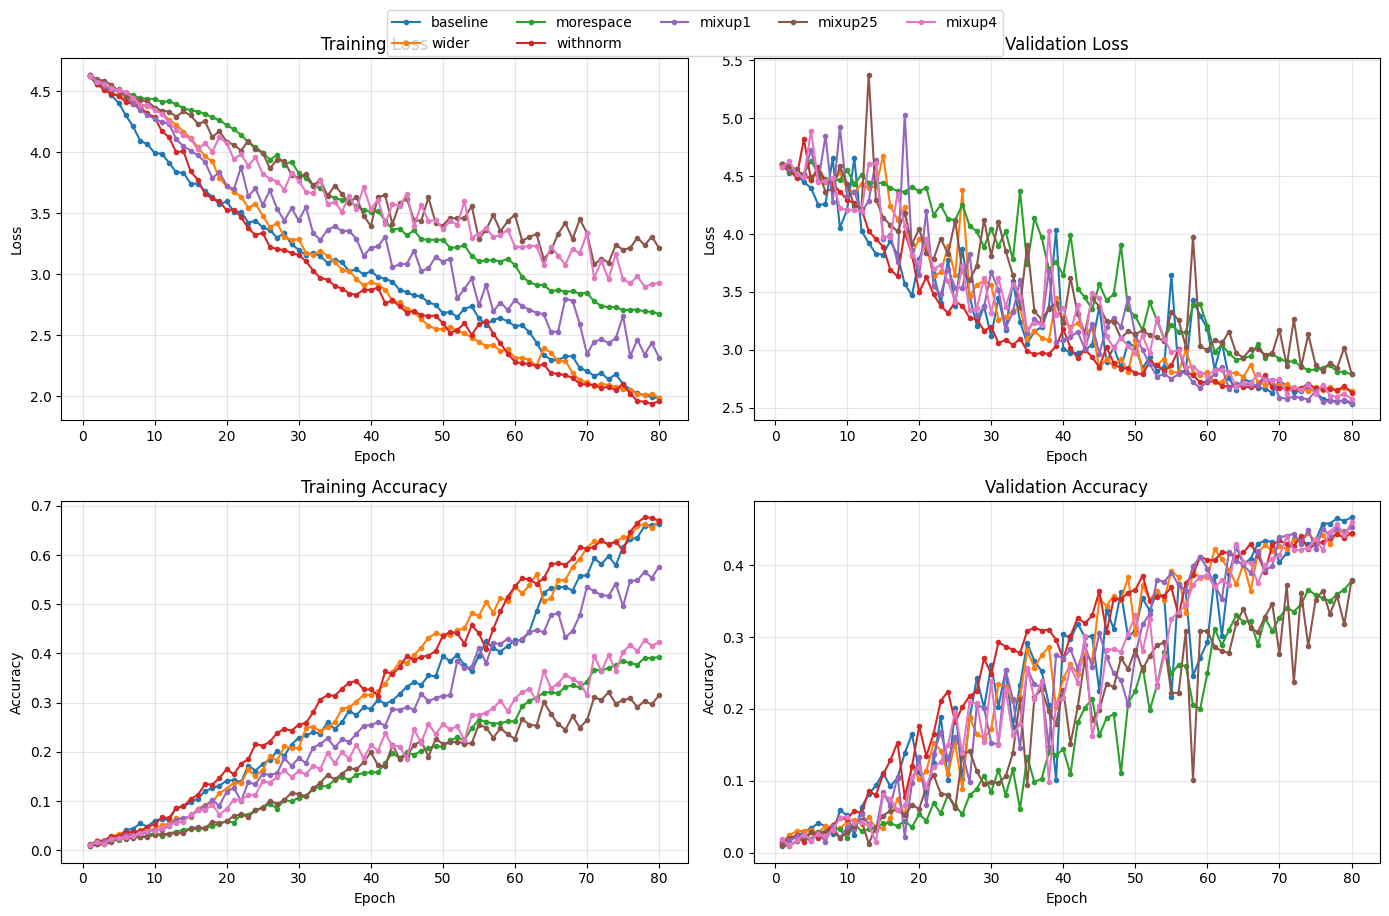

In [44]:

# Consistent color per config across all subplots
cmap = plt.get_cmap("tab10")
colors = {name: cmap(i % 10) for i, name in enumerate(results)}

def plot_metric(ax, key, title, ylabel):
    for name, data in results.items():
        y = data[key]
        ax.plot(range(1, len(y) + 1), y, label=name,
                color=colors[name], marker="o", ms=3, lw=1.5)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_metric(axes[0, 0], "train_loss",     "Training Loss",       "Loss")
plot_metric(axes[0, 1], "val_losses",     "Validation Loss",     "Loss")
plot_metric(axes[1, 0], "train_accuracy", "Training Accuracy",   "Accuracy")
plot_metric(axes[1, 1], "val_accuracy",   "Validation Accuracy", "Accuracy")

# One shared legend instead of four
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           ncol=min(len(results), 5), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

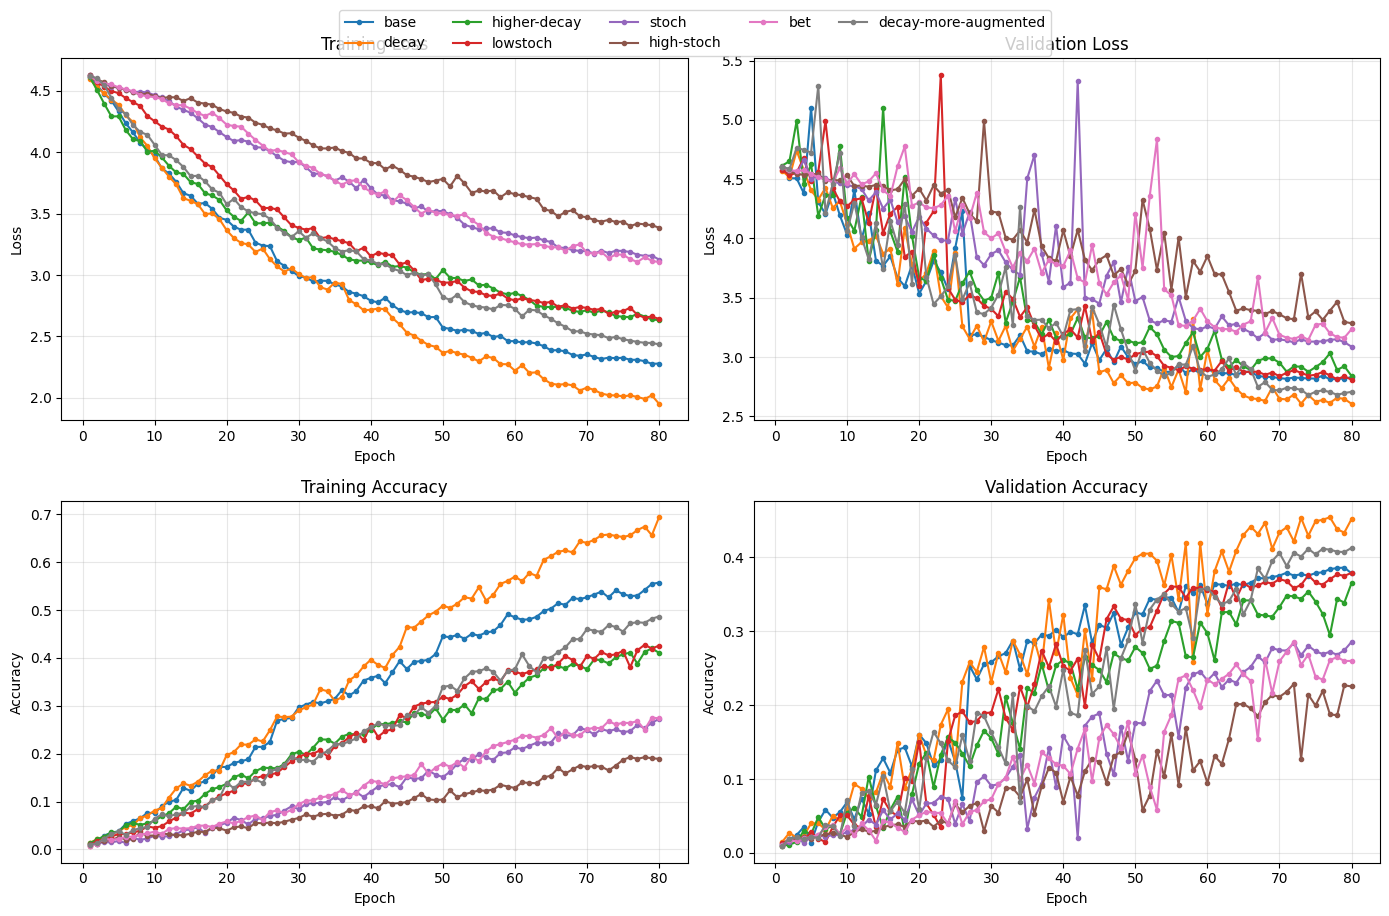

In [ ]:

# Consistent color per config across all subplots
cmap = plt.get_cmap("tab10")
colors = {name: cmap(i % 10) for i, name in enumerate(results)}

def plot_metric(ax, key, title, ylabel):
    for name, data in results.items():
        y = data[key]
        ax.plot(range(1, len(y) + 1), y, label=name,
                color=colors[name], marker="o", ms=3, lw=1.5)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_metric(axes[0, 0], "train_loss",     "Training Loss",       "Loss")
plot_metric(axes[0, 1], "val_losses",     "Validation Loss",     "Loss")
plot_metric(axes[1, 0], "train_accuracy", "Training Accuracy",   "Accuracy")
plot_metric(axes[1, 1], "val_accuracy",   "Validation Accuracy", "Accuracy")

# One shared legend instead of four
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           ncol=min(len(results), 5), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

#### Actual training

Total parameters: 225,244
epoch 1/50 loss=4.5640 accuracy=0.0172 val_loss=4.4663 val_accuracy=0.0267 time=103.5s eta=84.5min
epoch 2/50 loss=4.3757 accuracy=0.0393 val_loss=4.3862 val_accuracy=0.0387 time=103.1s eta=82.7min
epoch 3/50 loss=4.1217 accuracy=0.0507 val_loss=4.9975 val_accuracy=0.0177 time=103.1s eta=80.9min
epoch 4/50 loss=3.9581 accuracy=0.0688 val_loss=3.9023 val_accuracy=0.0882 time=102.5s eta=79.0min
epoch 5/50 loss=3.7905 accuracy=0.0999 val_loss=4.0864 val_accuracy=0.0708 time=102.0s eta=77.1min
epoch 6/50 loss=3.6589 accuracy=0.1191 val_loss=3.8460 val_accuracy=0.0921 time=103.0s eta=75.4min
epoch 7/50 loss=3.5564 accuracy=0.1380 val_loss=3.8819 val_accuracy=0.0996 time=103.6s eta=73.8min
epoch 8/50 loss=3.4655 accuracy=0.1539 val_loss=4.1025 val_accuracy=0.0690 time=103.0s eta=72.1min
epoch 9/50 loss=3.3425 accuracy=0.1837 val_loss=3.9043 val_accuracy=0.0849 time=102.4s eta=70.3min
epoch 10/50 loss=3.2987 accuracy=0.1954 val_loss=3.3254 val_accuracy=0.1977 time=10

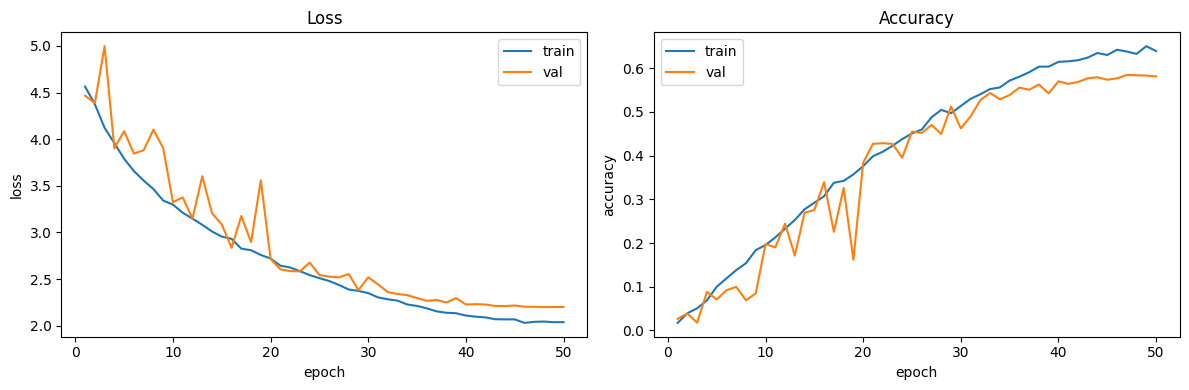

In [10]:
config = ExpConfig(
    stem_channels=(12, 24, 48), #->32x32
    stage_channels=(48, 96, 192), #->4x4
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=192,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR"
)

trainset,valset,testset = get_datasets(split_validation=False)
_, history, final_loss, final_accuracy = run_experiment(
    config,
    50,
    trainset,
    valset,
    testset,
    name="submission"
)
plot_results(history)

##### roba vecchia

In [9]:

# TRANSFORM = T.Compose([T.Resize((256, 256)), T.ToTensor()])
CONFIG = ExpConfig(
    stem_channels=(12, 24, 48), #->32x32
    stage_channels=(48, 96, 192), #->4x4
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=192,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
)

trainset = FGVCAircraft(
    root='./data',
    split = 'trainval',
    # split = 'train',
    annotation_level='variant',
    download=True,
    transform=AUGMENT_TRANSFORM
)
valset = FGVCAircraft(
    root='./data',
    split = 'val',
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)
testset = FGVCAircraft(
    root='./data',
    split = 'test',
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)
print(f"Loaded {len(trainset)} images")
trainloader = DataLoader(
    dataset=trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
valloader = DataLoader(
    # dataset=valset,
    dataset=testset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
# benchmark on the test set each 5 epochs to see the progression on test data
# history, callback = test_performance_callback(1, testset)
model, history = train(
    model=Cnn(CONFIG),
    train_loader=trainloader,
    val_loader=valloader,
    device=DEVICE,
    epochs=100,
    config=CONFIG,
)


loss, accuracy = evaluate(
    model,
    testset,
    # transform=TRANSFORM,
    batch_size=BATCH_SIZE
)

print(f"Final loss {loss}, accuracy {accuracy}")
# TODO make a proper plot of this
print(history["val_accuracy"])
print(history["val_loss"])


Loaded 6667 images
Total parameters: 225,244
epoch 1/100 loss=4.5726 accuracy=0.0139 val_loss=4.4990 val_accuracy=0.0195 time=103.8s eta=171.2min
epoch 2/100 loss=4.4613 accuracy=0.0225 val_loss=4.6832 val_accuracy=0.0150 time=107.3s eta=172.4min
epoch 3/100 loss=4.3047 accuracy=0.0387 val_loss=4.8430 val_accuracy=0.0216 time=104.2s eta=169.9min
epoch 4/100 loss=4.1109 accuracy=0.0543 val_loss=4.0602 val_accuracy=0.0579 time=104.2s eta=167.8min
epoch 5/100 loss=3.9778 accuracy=0.0727 val_loss=4.1053 val_accuracy=0.0651 time=104.0s eta=165.8min
epoch 6/100 loss=3.7973 accuracy=0.0892 val_loss=4.5476 val_accuracy=0.0453 time=103.4s eta=163.7min
epoch 7/100 loss=3.6963 accuracy=0.1119 val_loss=3.9464 val_accuracy=0.0783 time=104.2s eta=161.9min
epoch 8/100 loss=3.5943 accuracy=0.1219 val_loss=3.6591 val_accuracy=0.1326 time=103.2s eta=159.9min
epoch 9/100 loss=3.5134 accuracy=0.1435 val_loss=3.4962 val_accuracy=0.1470 time=103.5s eta=158.1min
epoch 10/100 loss=3.4172 accuracy=0.1666 val_l

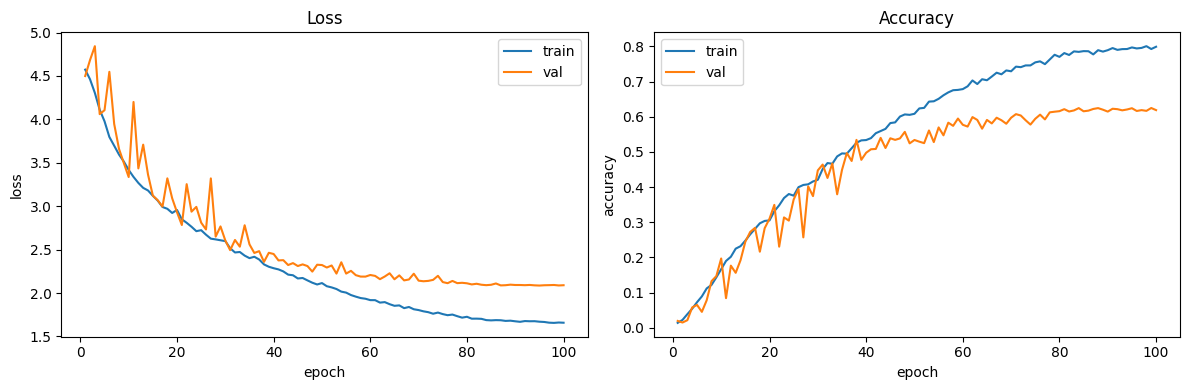

In [10]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history["train_loss"]) + 1)

ax_loss.plot(epochs_range, history["train_loss"], label="train")
ax_loss.plot(epochs_range, history["val_loss"], label="val")
ax_loss.set_xlabel("epoch")
ax_loss.set_ylabel("loss")
ax_loss.set_title("Loss")
ax_loss.legend()

ax_acc.plot(epochs_range, history["train_accuracy"], label="train")
ax_acc.plot(epochs_range, history["val_accuracy"], label="val")
ax_acc.set_xlabel("epoch")
ax_acc.set_ylabel("accuracy")
ax_acc.set_title("Accuracy")
ax_acc.legend()

fig.tight_layout()
plt.show()


In [14]:

# TRANSFORM = T.Compose([T.Resize((256, 256)), T.ToTensor()])
CONFIG = ExpConfig(
    stem_channels=(16, 32, 64), #->32x32
    stage_channels=(64, 128, 256), #->4x4
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=256,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR"
)

trainset = FGVCAircraft(
    root='./data',
    split = 'trainval',
    # split = 'train',
    annotation_level='variant',
    download=True,
    transform=AUGMENT_TRANSFORM
)
valset = FGVCAircraft(
    root='./data',
    split = 'val',
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)
testset = FGVCAircraft(
    root='./data',
    split = 'test',
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)
print(f"Loaded {len(trainset)} images")
trainloader = DataLoader(
    dataset=trainset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
valloader = DataLoader(
    # dataset=valset,
    dataset=testset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)
# benchmark on the test set each 5 epochs to see the progression on test data
# history, callback = test_performance_callback(1, testset)
model, history = train(
    model=Cnn(CONFIG),
    train_loader=trainloader,
    val_loader=valloader,
    device=DEVICE,
    epochs=60,
    config=CONFIG,
)


loss, accuracy = evaluate(
    model,
    testset,
    # transform=TRANSFORM,
    batch_size=BATCH_SIZE
)

print(f"Final loss {loss}, accuracy {accuracy}")
# TODO make a proper plot of this
print(history["val_accuracy"])
print(history["val_loss"])


Loaded 6667 images
Total parameters: 390,660
epoch 1/60 loss=4.5723 accuracy=0.0151 val_loss=4.5335 val_accuracy=0.0171 time=108.3s eta=106.5min
epoch 2/60 loss=4.4905 accuracy=0.0196 val_loss=4.4524 val_accuracy=0.0267 time=108.0s eta=104.5min
epoch 3/60 loss=4.4103 accuracy=0.0330 val_loss=4.3388 val_accuracy=0.0345 time=106.8s eta=102.3min
epoch 4/60 loss=4.2230 accuracy=0.0412 val_loss=4.9183 val_accuracy=0.0201 time=109.9s eta=101.0min
epoch 5/60 loss=3.9844 accuracy=0.0661 val_loss=3.9700 val_accuracy=0.0750 time=110.6s eta=99.7min
epoch 6/60 loss=3.8238 accuracy=0.0859 val_loss=4.6553 val_accuracy=0.0270 time=107.5s eta=97.7min
epoch 7/60 loss=3.6998 accuracy=0.1066 val_loss=3.8104 val_accuracy=0.0906 time=105.1s eta=95.4min
epoch 8/60 loss=3.5795 accuracy=0.1320 val_loss=3.9282 val_accuracy=0.0816 time=104.9s eta=93.3min
epoch 9/60 loss=3.4837 accuracy=0.1557 val_loss=4.2358 val_accuracy=0.0666 time=104.2s eta=91.2min
epoch 10/60 loss=3.3658 accuracy=0.1851 val_loss=3.7577 val_

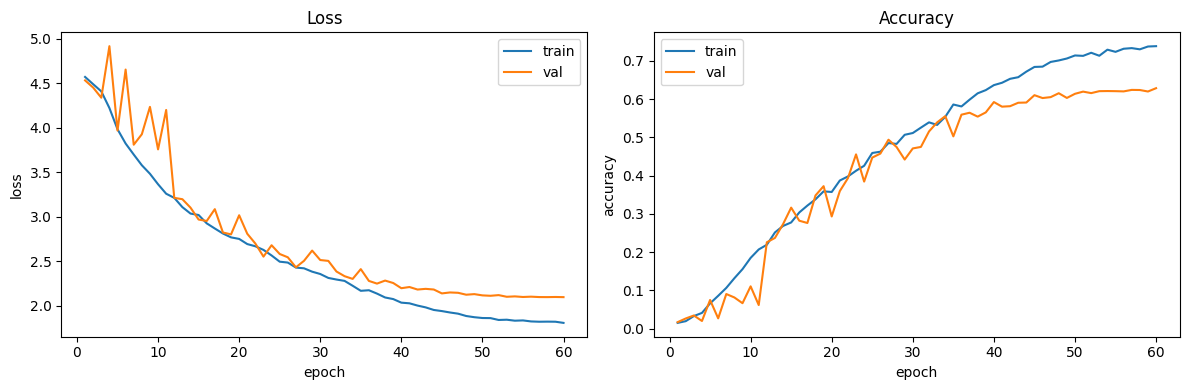

In [15]:
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, len(history["train_loss"]) + 1)

ax_loss.plot(epochs_range, history["train_loss"], label="train")
ax_loss.plot(epochs_range, history["val_loss"], label="val")
ax_loss.set_xlabel("epoch")
ax_loss.set_ylabel("loss")
ax_loss.set_title("Loss")
ax_loss.legend()

ax_acc.plot(epochs_range, history["train_accuracy"], label="train")
ax_acc.plot(epochs_range, history["val_accuracy"], label="val")
ax_acc.set_xlabel("epoch")
ax_acc.set_ylabel("accuracy")
ax_acc.set_title("Accuracy")
ax_acc.legend()

fig.tight_layout()
plt.show()


##### scale down

Total parameters: 71,644
epoch 1/50 loss=4.5938 accuracy=0.0159 val_loss=4.5839 val_accuracy=0.0183 time=106.3s eta=86.8min
epoch 2/50 loss=4.5199 accuracy=0.0249 val_loss=4.5421 val_accuracy=0.0252 time=103.0s eta=83.7min
epoch 3/50 loss=4.4674 accuracy=0.0286 val_loss=4.5332 val_accuracy=0.0309 time=102.9s eta=81.5min
epoch 4/50 loss=4.4349 accuracy=0.0343 val_loss=4.6298 val_accuracy=0.0306 time=103.2s eta=79.6min
epoch 5/50 loss=4.3784 accuracy=0.0423 val_loss=4.4134 val_accuracy=0.0399 time=105.6s eta=78.1min
epoch 6/50 loss=4.2650 accuracy=0.0495 val_loss=4.2528 val_accuracy=0.0600 time=102.9s eta=76.3min
epoch 7/50 loss=4.0998 accuracy=0.0621 val_loss=4.5208 val_accuracy=0.0387 time=102.6s eta=74.4min
epoch 8/50 loss=3.9857 accuracy=0.0735 val_loss=3.9051 val_accuracy=0.0879 time=102.6s eta=72.5min
epoch 9/50 loss=3.9074 accuracy=0.0870 val_loss=3.9065 val_accuracy=0.0927 time=102.7s eta=70.8min
epoch 10/50 loss=3.8290 accuracy=0.0967 val_loss=4.0020 val_accuracy=0.0699 time=101

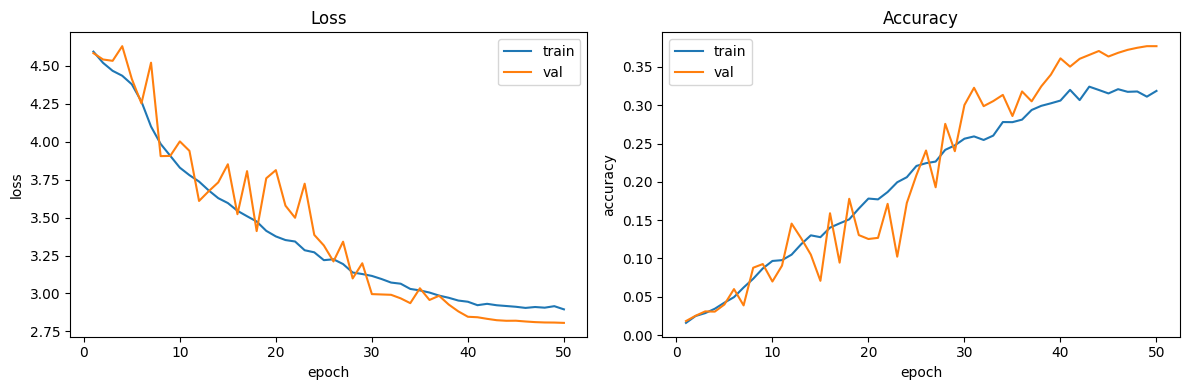

In [13]:
# -1 layer
config = ExpConfig(
    stem_channels=(12, 24, 48), #->32x32
    stage_channels=(48, 96), #->8x8
    stage_stride=(2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=96,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR"
)

trainset,valset,testset = get_datasets(split_validation=False)
_, history, final_loss, final_accuracy = run_experiment(
    config,
    50,
    trainset,
    valset,
    testset,
    name="submission"
)
plot_results(history)

Total parameters: 132,372
epoch 1/50 loss=4.5760 accuracy=0.0183 val_loss=4.5360 val_accuracy=0.0186 time=99.3s eta=81.1min
epoch 2/50 loss=4.5069 accuracy=0.0252 val_loss=4.5011 val_accuracy=0.0282 time=98.7s eta=79.2min
epoch 3/50 loss=4.4753 accuracy=0.0265 val_loss=4.4491 val_accuracy=0.0363 time=98.8s eta=77.5min
epoch 4/50 loss=4.4163 accuracy=0.0316 val_loss=4.3868 val_accuracy=0.0363 time=98.9s eta=75.8min
epoch 5/50 loss=4.3279 accuracy=0.0423 val_loss=4.4781 val_accuracy=0.0261 time=99.3s eta=74.2min
epoch 6/50 loss=4.2117 accuracy=0.0465 val_loss=4.6884 val_accuracy=0.0324 time=98.7s eta=72.6min
epoch 7/50 loss=4.1129 accuracy=0.0616 val_loss=4.1579 val_accuracy=0.0450 time=99.2s eta=70.9min
epoch 8/50 loss=4.0222 accuracy=0.0688 val_loss=4.2067 val_accuracy=0.0672 time=98.6s eta=69.2min
epoch 9/50 loss=3.9239 accuracy=0.0772 val_loss=4.2830 val_accuracy=0.0516 time=99.3s eta=67.6min
epoch 10/50 loss=3.8532 accuracy=0.0871 val_loss=4.0596 val_accuracy=0.0726 time=99.3s eta=6

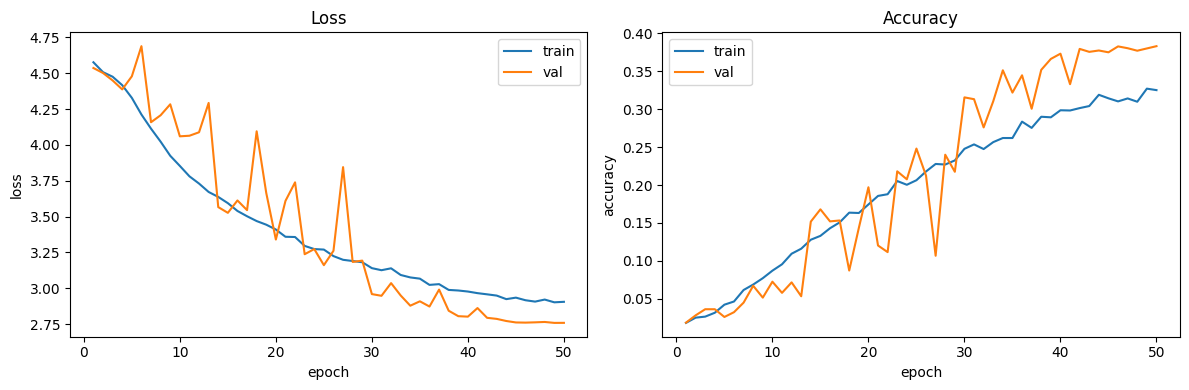

In [14]:
# -1 layer ma largo
config = ExpConfig(
    stem_channels=(12, 24, 48), #->32x32
    stage_channels=(96, 128), #->8x8
    stage_stride=(2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=128,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR"
)

trainset,valset,testset = get_datasets(split_validation=False)
_, history, final_loss, final_accuracy = run_experiment(
    config,
    50,
    trainset,
    valset,
    testset,
    name="submission"
)
plot_results(history)

Total parameters: 89,916
epoch 1/50 loss=4.5728 accuracy=0.0172 val_loss=4.5356 val_accuracy=0.0252 time=98.2s eta=80.2min
epoch 2/50 loss=4.4759 accuracy=0.0262 val_loss=4.4912 val_accuracy=0.0279 time=98.6s eta=78.7min
epoch 3/50 loss=4.3612 accuracy=0.0340 val_loss=4.3516 val_accuracy=0.0375 time=98.4s eta=77.1min
epoch 4/50 loss=4.2154 accuracy=0.0499 val_loss=4.4789 val_accuracy=0.0345 time=98.5s eta=75.5min
epoch 5/50 loss=4.0695 accuracy=0.0598 val_loss=4.1579 val_accuracy=0.0483 time=98.9s eta=73.9min
epoch 6/50 loss=3.9337 accuracy=0.0757 val_loss=3.8732 val_accuracy=0.0909 time=98.6s eta=72.3min
epoch 7/50 loss=3.8207 accuracy=0.0873 val_loss=4.2191 val_accuracy=0.0543 time=99.1s eta=70.7min
epoch 8/50 loss=3.7029 accuracy=0.1015 val_loss=3.8881 val_accuracy=0.0864 time=98.5s eta=69.0min
epoch 9/50 loss=3.6310 accuracy=0.1225 val_loss=4.1312 val_accuracy=0.0831 time=98.4s eta=67.4min
epoch 10/50 loss=3.5509 accuracy=0.1324 val_loss=3.5007 val_accuracy=0.1524 time=98.1s eta=65

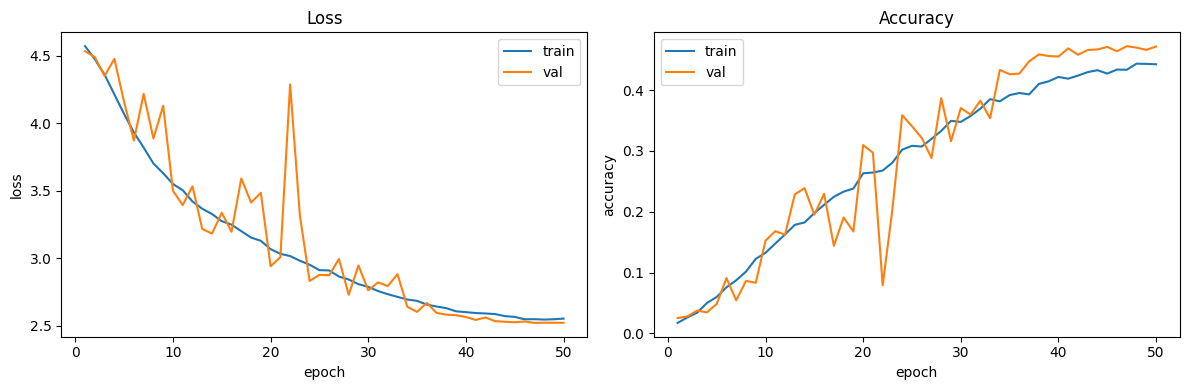

In [15]:
# magro
config = ExpConfig(
    stem_channels=(12, 24, 48), #->32x32
    stage_channels=(48, 64, 96), #->4x4
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=96,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR"
)

trainset,valset,testset = get_datasets(split_validation=False)
_, history, final_loss, final_accuracy = run_experiment(
    config,
    50,
    trainset,
    valset,
    testset,
    name="submission"
)
plot_results(history)

### Ablation

#### No regularization

Total parameters: 225,244
epoch 1/50 loss=4.5429 accuracy=0.0186 val_loss=4.4654 val_accuracy=0.0225 time=101.5s eta=82.9min
epoch 2/50 loss=4.3695 accuracy=0.0354 val_loss=4.6414 val_accuracy=0.0246 time=101.6s eta=81.2min
epoch 3/50 loss=4.1150 accuracy=0.0475 val_loss=4.6694 val_accuracy=0.0351 time=103.3s eta=80.0min
epoch 4/50 loss=3.7432 accuracy=0.0801 val_loss=4.0092 val_accuracy=0.0681 time=101.4s eta=78.2min
epoch 5/50 loss=3.4027 accuracy=0.1209 val_loss=3.8706 val_accuracy=0.0798 time=100.0s eta=76.2min
epoch 6/50 loss=3.1715 accuracy=0.1531 val_loss=3.9221 val_accuracy=0.0897 time=99.1s eta=74.2min
epoch 7/50 loss=2.9217 accuracy=0.1971 val_loss=3.5747 val_accuracy=0.1362 time=99.3s eta=72.3min
epoch 8/50 loss=2.7872 accuracy=0.2269 val_loss=3.1607 val_accuracy=0.1812 time=99.2s eta=70.5min
epoch 9/50 loss=2.6216 accuracy=0.2634 val_loss=2.7960 val_accuracy=0.2388 time=99.1s eta=68.7min
epoch 10/50 loss=2.4526 accuracy=0.2901 val_loss=3.3010 val_accuracy=0.1566 time=99.0s 

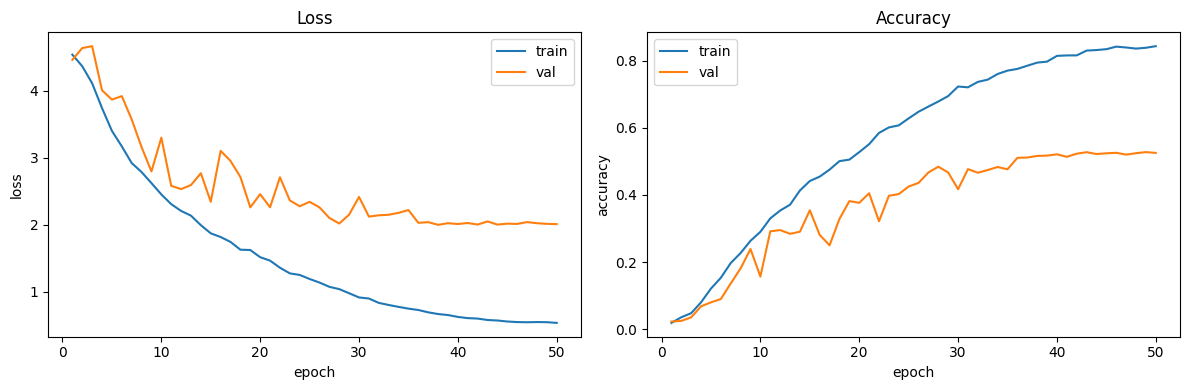

In [19]:
config = ExpConfig(
    stem_channels=(12, 24, 48),
    stage_channels=(48, 96, 192),
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=192,
    label_smoothing=0.0,
    dropout=0.0,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=0.0,
    scheduler="CosineAnnealingLR"
)

trainset,valset,testset = get_datasets(split_validation=False)
_, history, final_loss, final_accuracy = run_experiment(config, 50, trainset,valset,testset)
plot_results(history)

Total parameters: 225,244
epoch 1/60 loss=4.5367 accuracy=0.0190 val_loss=5.0793 val_accuracy=0.0123 time=106.2s eta=104.4min
epoch 2/60 loss=4.3289 accuracy=0.0346 val_loss=4.2274 val_accuracy=0.0417 time=106.0s eta=102.5min
epoch 3/60 loss=3.9578 accuracy=0.0592 val_loss=4.0311 val_accuracy=0.0564 time=102.8s eta=99.7min
epoch 4/60 loss=3.5729 accuracy=0.0987 val_loss=3.7401 val_accuracy=0.0969 time=103.4s eta=97.6min
epoch 5/60 loss=3.2604 accuracy=0.1398 val_loss=4.2744 val_accuracy=0.0720 time=104.7s eta=95.9min
epoch 6/60 loss=3.0029 accuracy=0.1762 val_loss=3.5337 val_accuracy=0.1347 time=103.7s eta=94.0min
epoch 7/60 loss=2.8486 accuracy=0.2089 val_loss=3.2262 val_accuracy=0.1794 time=101.8s eta=91.9min
epoch 8/60 loss=2.6401 accuracy=0.2536 val_loss=2.8666 val_accuracy=0.2256 time=104.6s eta=90.3min
epoch 9/60 loss=2.4455 accuracy=0.3004 val_loss=4.6505 val_accuracy=0.0546 time=105.5s eta=88.7min
epoch 10/60 loss=2.3367 accuracy=0.3289 val_loss=2.8255 val_accuracy=0.2337 time=

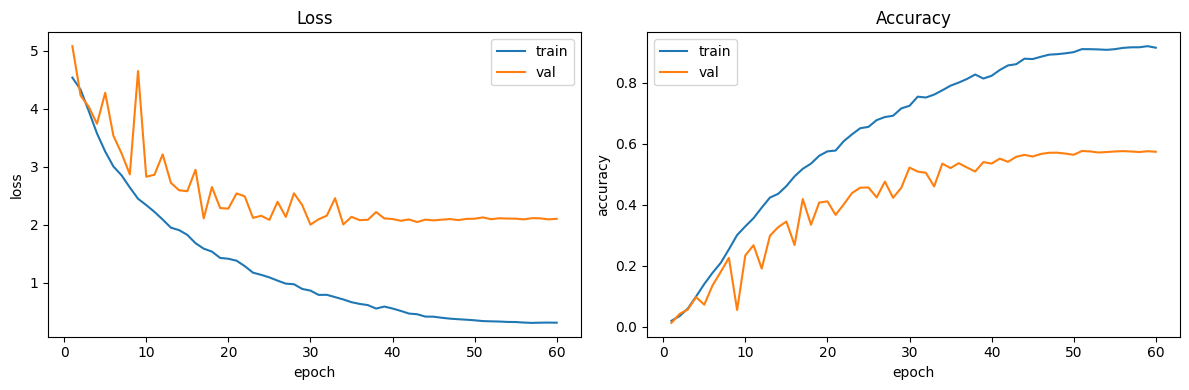

In [ ]:
config = ExpConfig(
    stem_channels=(12, 24, 48),
    stage_channels=(48, 96, 192),
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=192,
    label_smoothing=0.0,
    dropout=0.0,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=0.0,
    scheduler="CosineAnnealingLR"
)

trainset,valset,testset = get_datasets(split_validation=False)
_, history, final_loss, final_accuracy = run_experiment(config, 60, trainset,valset,testset)
plot_results(history)

#### Held-out validation with ReduceLROnPlateau schedule

In [56]:
config = ExpConfig(
    model=NetworkConfig(
        stem_channels=(12, 24, 48), #->32x32
        stage_channels=(48, 96, 192, 256), #->8x8
        stage_stride=(1,1,2,2),
        canonical_size=CANONICAL_SIZE,
        block_type="inception",
        classifier_hidden_dim=256,
        dropout=0.4,
        stochastic_depth=0.0,
        pooling='avg',
    ),
    train=TrainConfig(
        learning_rate=0.005,
        weight_decay=1e-4,
        scheduler="ReduceLROnPlateau",
        label_smoothing=0.1,
        mixup_alpha=0.4,
        train_transform=T.Compose([
            T.Resize((256, 256)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ToTensor(),
        ])
    )
)

trainset,valset,testset = get_datasets(split_validation=True)
_, history, final_loss, final_accuracy = run_experiment(config, 120, True, name="val-heldout")
plot_results(history)

Total parameters: 499,356
epoch 1/120 loss=4.6216 accuracy=0.0101 val_loss=4.6064 val_accuracy=0.0111 time=71.9s eta=142.5min
epoch 2/120 loss=4.5920 accuracy=0.0125 val_loss=4.6281 val_accuracy=0.0144 time=73.6s eta=143.0min


KeyboardInterrupt: 

Total parameters: 243,996
epoch 1/120 loss=4.5952 accuracy=0.0129 val_loss=4.5642 val_accuracy=0.0186 time=64.9s eta=128.8min
epoch 2/120 loss=4.5295 accuracy=0.0249 val_loss=4.5254 val_accuracy=0.0201 time=64.9s eta=127.7min
epoch 3/120 loss=4.4797 accuracy=0.0261 val_loss=4.9032 val_accuracy=0.0180 time=64.6s eta=126.4min
epoch 4/120 loss=4.4563 accuracy=0.0312 val_loss=4.4597 val_accuracy=0.0327 time=65.2s eta=125.5min
epoch 5/120 loss=4.4010 accuracy=0.0342 val_loss=4.9130 val_accuracy=0.0162 time=64.6s eta=124.3min
epoch 6/120 loss=4.3528 accuracy=0.0489 val_loss=4.6425 val_accuracy=0.0210 time=65.0s eta=123.3min
epoch 7/120 loss=4.2746 accuracy=0.0495 val_loss=4.4047 val_accuracy=0.0381 time=64.6s eta=122.1min
epoch 8/120 loss=4.2166 accuracy=0.0558 val_loss=4.3445 val_accuracy=0.0459 time=65.1s eta=121.1min
epoch 9/120 loss=4.1373 accuracy=0.0651 val_loss=4.4661 val_accuracy=0.0375 time=65.0s eta=120.0min
epoch 10/120 loss=4.0139 accuracy=0.0780 val_loss=4.1651 val_accuracy=0.06

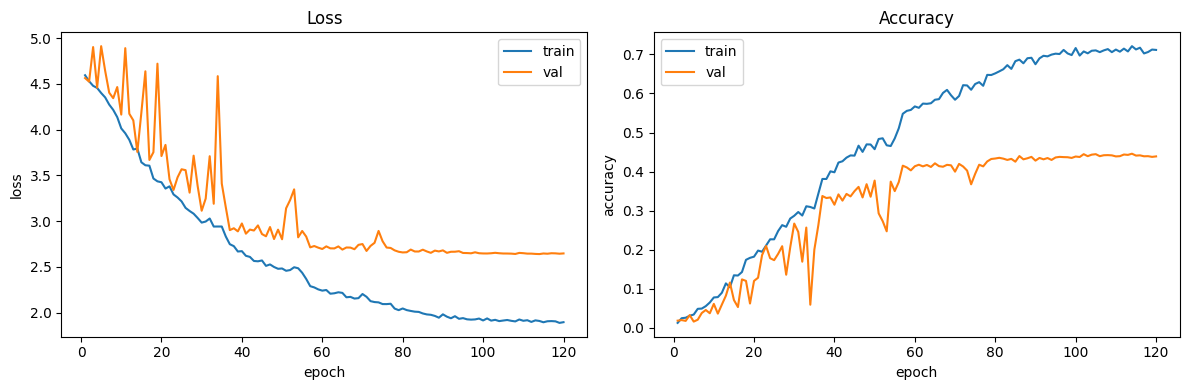

In [18]:
config = ExpConfig(
    stem_channels=(12, 24, 48),
    stage_channels=(48, 96, 192),
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=256,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="ReduceLROnPlateau"
)

trainset,valset,testset = get_datasets(split_validation=True)
_, history, final_loss, final_accuracy = run_experiment(config, 120, trainset,valset,testset)
plot_results(history)

#### No schedule at all

Total parameters: 243,996
epoch 1/50 loss=4.6122 accuracy=0.0138 val_loss=4.6028 val_accuracy=0.0120 time=64.7s eta=52.8min
epoch 2/50 loss=4.5260 accuracy=0.0198 val_loss=4.8940 val_accuracy=0.0102 time=65.1s eta=51.9min
epoch 3/50 loss=4.4719 accuracy=0.0285 val_loss=5.0816 val_accuracy=0.0159 time=64.8s eta=50.8min
epoch 4/50 loss=4.4174 accuracy=0.0324 val_loss=4.3715 val_accuracy=0.0336 time=64.9s eta=49.7min
epoch 5/50 loss=4.3169 accuracy=0.0375 val_loss=5.0717 val_accuracy=0.0153 time=64.9s eta=48.7min
epoch 6/50 loss=4.2495 accuracy=0.0438 val_loss=4.7143 val_accuracy=0.0180 time=64.7s eta=47.6min
epoch 7/50 loss=4.1488 accuracy=0.0543 val_loss=4.4525 val_accuracy=0.0321 time=65.3s eta=46.5min
epoch 8/50 loss=4.0658 accuracy=0.0618 val_loss=4.1766 val_accuracy=0.0570 time=65.4s eta=45.5min
epoch 9/50 loss=3.9828 accuracy=0.0720 val_loss=4.2499 val_accuracy=0.0495 time=65.2s eta=44.4min
epoch 10/50 loss=3.9151 accuracy=0.0816 val_loss=4.0847 val_accuracy=0.0615 time=65.4s eta=4

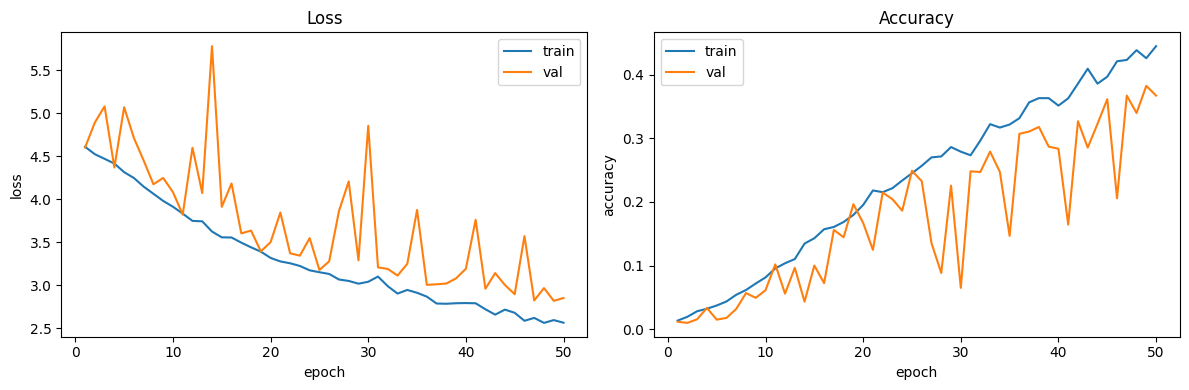

In [16]:
config = ExpConfig(
    stem_channels=(12, 24, 48),
    stage_channels=(48, 96, 192),
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=256,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler=None,
)

trainset,valset,testset = get_datasets(split_validation=True)
_, history, final_loss, final_accuracy = run_experiment(config, 50, trainset,valset,testset)
plot_results(history)

#### No augmentation

Total parameters: 243,996
epoch 1/50 loss=4.5594 accuracy=0.0181 val_loss=4.4450 val_accuracy=0.0288 time=97.2s eta=79.4min
epoch 2/50 loss=4.3161 accuracy=0.0385 val_loss=4.2310 val_accuracy=0.0402 time=97.3s eta=77.8min
epoch 3/50 loss=4.0408 accuracy=0.0606 val_loss=4.8863 val_accuracy=0.0237 time=97.4s eta=76.2min
epoch 4/50 loss=3.8378 accuracy=0.0802 val_loss=5.1890 val_accuracy=0.0192 time=98.3s eta=74.8min
epoch 5/50 loss=3.6757 accuracy=0.1039 val_loss=3.9990 val_accuracy=0.0765 time=97.3s eta=73.1min
epoch 6/50 loss=3.5805 accuracy=0.1200 val_loss=3.5504 val_accuracy=0.1344 time=98.0s eta=71.6min
epoch 7/50 loss=3.4202 accuracy=0.1614 val_loss=3.7685 val_accuracy=0.1059 time=97.9s eta=70.0min
epoch 8/50 loss=3.3286 accuracy=0.1833 val_loss=3.5664 val_accuracy=0.1515 time=98.0s eta=68.4min
epoch 9/50 loss=3.2297 accuracy=0.2023 val_loss=3.6820 val_accuracy=0.1338 time=97.9s eta=66.8min
epoch 10/50 loss=3.1308 accuracy=0.2358 val_loss=3.5987 val_accuracy=0.1491 time=97.6s eta=6

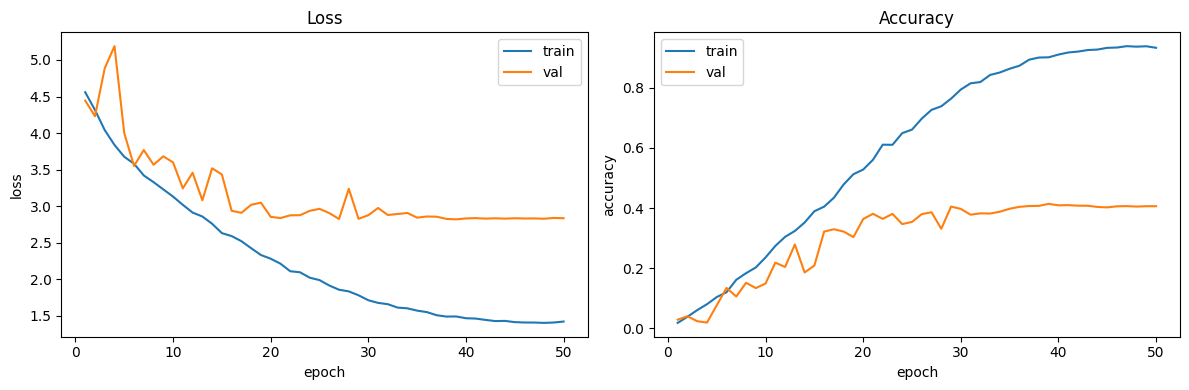

In [17]:
config = ExpConfig(
    stem_channels=(12, 24, 48),
    stage_channels=(48, 96, 192),
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=256,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR"
)

_,valset,testset = get_datasets(split_validation=False)
trainset = FGVCAircraft(
    root='./data',
    split = "trainval",
    annotation_level='variant',
    download=True,
    transform=TRANSFORM
)
_, history, final_loss, final_accuracy = run_experiment(config, 50, trainset,valset,testset)
plot_results(history)

#### Size-matched resnet

In [ ]:
config = ExpConfig(
    stem_channels=(12, 24, 48),
    stage_channels=(48, 96, 192),
    stage_stride=(2,2,2),
    canonical_size=CANONICAL_SIZE,
    block_type="inception",
    classifier_hidden_dim=256,
    label_smoothing=0.1,
    dropout=0.4,
    stochastic_depth=0.0,
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR"
)

trainset,valset,testset = get_datasets(split_validation=False)
_, history = run_experiment(config, 50, trainset,valset,testset)
plot_results(history)

## Part 2: fine-tune an existing network

Your goal is to fine-tune a pretrained ResNet-18 model on `FGVCAircraft`. Use the implementation provided by PyTorch, i.e. the opposite of part 1. Specifically, use the PyTorch ResNet-18 model pretrained on ImageNet-1K (V1). Divide your fine-tuning into two parts:

2A. First, fine-tune the ResNet-18 with the same training hyperparameters you used for your best model in part 1.

2B. Then, tweak the training hyperparameters to increase the accuracy on the test split. Justify your choices by analyzing the training plots and/or citing sources that guided you in your decisions — papers, blog posts, YouTube videos, or whatever else you may find useful. You should consider yourselves satisfied once you obtain a classification accuracy on the test split of ~70%.

### Same parameters

In [46]:
NUM_CLASSES = 100

def build_resnet():
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model


@dataclass
class FinetuneConfig:
    """Hyperparameters for the finetuning run in `finetune.py`."""

    lr_backbone: float = 1e-4
    lr_head: float = 1e-3
    weight_decay: float = 0.0
    scheduler: Literal["ReduceLROnPlateau", "CosineAnnealingLR"] = "ReduceLROnPlateau"
    label_smoothing: float = 0.0
    train_transform: T.Compose = None
    mixup_alpha: float = 0.0
    epochs: int = 1
    split_validation: bool = True
    batch_size: int = 128


def finetune(
    model,
    device,
    config: FinetuneConfig,
):
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")

    backbone_params = [
        p for name, p in model.named_parameters() if not name.startswith("fc.")
    ]
    head_params = list(model.fc.parameters())

    for param in backbone_params:
        param.requires_grad = config.lr_backbone != 0
    for param in head_params:
        param.requires_grad = config.lr_head != 0

    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Trainable parameters: {trainable_params:,}")

    train_loader, val_loader, _ = get_loaders(
        config.train_transform, config.split_validation, config.batch_size
    )

    param_groups = []
    if config.lr_backbone != 0:
        param_groups.append({"params": backbone_params, "lr": config.lr_backbone})
    if config.lr_head != 0:
        param_groups.append({"params": head_params, "lr": config.lr_head})

    criterion = nn.CrossEntropyLoss(label_smoothing=config.label_smoothing)
    optimizer = Adam(param_groups, weight_decay=config.weight_decay)
    scheduler = get_scheduler(config.scheduler, optimizer, config.epochs)

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
    }
    epoch_durations = []

    for epoch in range(config.epochs):
        start = time.perf_counter()
        train_loss, train_accuracy = _run_epoch(
            model,
            train_loader,
            criterion,
            optimizer=optimizer,
            device=device,
            mixup_alpha=config.mixup_alpha,
        )
        val_loss, val_accuracy = _run_epoch(model, val_loader, criterion, device=device)
        duration = time.perf_counter() - start
        epoch_durations.append(duration)

        if scheduler is not None:
            if config.scheduler == "ReduceLROnPlateau":
                scheduler.step(val_loss)
            elif scheduler:
                scheduler.step()

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        avg_duration = sum(epoch_durations) / len(epoch_durations)
        eta = avg_duration * (config.epochs - epoch - 1)
        print(
            f"epoch {epoch + 1}/{config.epochs} loss={train_loss:.4f} accuracy={train_accuracy:.4f} "
            f"val_loss={val_loss:.4f} val_accuracy={val_accuracy:.4f} "
            f"time={duration:.1f}s eta={eta / 60:.1f}min"
        )

    return model, history


def run_experiment(
        model,
        config,
        testset,
        name=None
):

    model, history = finetune(
        model=model,
        device=DEVICE,
        config=config,
    )
    print("Train run finished")

    loss, accuracy = evaluate(
        model,
        testset,
        batch_size=BATCH_SIZE
    )

    print("Evaluation on test set finished")
    print(f"Final loss: {loss}")
    print(f"Final accuracy: {accuracy}")

    if name:
        store_weights(name, model)
        store_results(name, history, loss, accuracy)

    return model, history, loss, accuracy



### sweep

In [ ]:
# comment this to preserve the previous run so they can be plot together
ft_results = {}

configs = [
    ("baseline", FinetuneConfig(
        epochs=60,
        lr_backbone=1e-4,
        lr_head=1e-3,
        weight_decay=1e-4,
        label_smoothing=0.1,
        mixup_alpha=0.0,
        train_transform=T.Compose([
            T.Resize((256, 256)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ToTensor(),
        ]),
    )),
    ("heavymixup", FinetuneConfig(
        epochs=60,
        lr_backbone=1e-4,
        lr_head=1e-3,
        weight_decay=1e-4,
        label_smoothing=0.1,
        mixup_alpha=0.4,
        train_transform=T.Compose([
            T.Resize((256, 256)),
            T.RandomHorizontalFlip(),
            T.RandomRotation(10),
            T.ToTensor(),
        ]),
    )),

]


for name, c in configs:
    resnet = build_resnet()
    _, history = finetune(
        resnet,
        device=DEVICE,
        config=c,
    )
    ft_results[name] = {
        "train_loss": history["train_loss"],
        "train_accuracy": history["train_accuracy"],
        "val_losses": history["val_loss"],
        "val_accuracy": history["val_accuracy"],
    }

Total parameters: 11,227,812
Trainable parameters: 51,300
epoch 1/60 loss=4.6643 accuracy=0.0186 val_loss=4.5237 val_accuracy=0.0351 time=71.3s eta=70.2min
epoch 2/60 loss=4.3269 accuracy=0.0813 val_loss=4.2809 val_accuracy=0.0912 time=71.1s eta=68.9min
epoch 3/60 loss=4.0841 accuracy=0.1338 val_loss=4.1239 val_accuracy=0.1284 time=71.4s eta=67.7min
epoch 4/60 loss=3.8985 accuracy=0.1935 val_loss=4.0054 val_accuracy=0.1488 time=71.4s eta=66.6min
epoch 5/60 loss=3.7273 accuracy=0.2223 val_loss=3.8878 val_accuracy=0.1800 time=71.0s eta=65.3min
epoch 6/60 loss=3.5880 accuracy=0.2720 val_loss=3.8108 val_accuracy=0.1965 time=71.0s eta=64.1min
epoch 7/60 loss=3.4517 accuracy=0.2921 val_loss=3.7333 val_accuracy=0.2043 time=71.3s eta=62.9min
epoch 8/60 loss=3.3422 accuracy=0.3284 val_loss=3.6653 val_accuracy=0.2208 time=71.0s eta=61.7min
epoch 9/60 loss=3.2480 accuracy=0.3599 val_loss=3.6043 val_accuracy=0.2289 time=72.0s eta=60.6min
epoch 10/60 loss=3.1676 accuracy=0.3749 val_loss=3.5724 val_

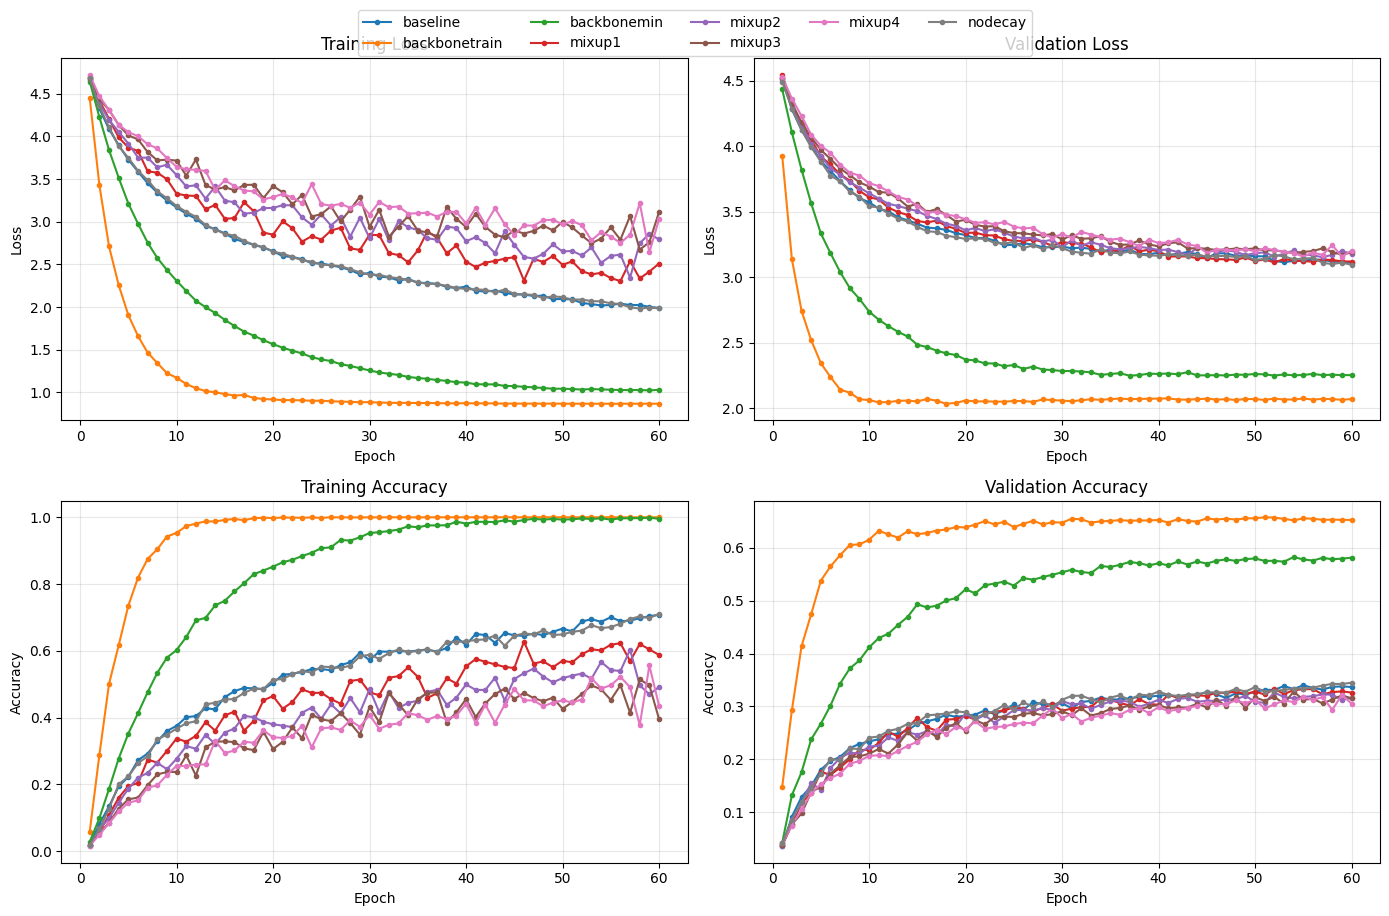

In [51]:

# Consistent color per config across all subplots
cmap = plt.get_cmap("tab10")
colors = {name: cmap(i % 10) for i, name in enumerate(ft_results)}

def plot_metric(ax, key, title, ylabel):
    for name, data in ft_results.items():
        y = data[key]
        ax.plot(range(1, len(y) + 1), y, label=name,
                color=colors[name], marker="o", ms=3, lw=1.5)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
plot_metric(axes[0, 0], "train_loss",     "Training Loss",       "Loss")
plot_metric(axes[0, 1], "val_losses",     "Validation Loss",     "Loss")
plot_metric(axes[1, 0], "train_accuracy", "Training Accuracy",   "Accuracy")
plot_metric(axes[1, 1], "val_accuracy",   "Validation Accuracy", "Accuracy")

# One shared legend instead of four
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center",
           ncol=min(len(ft_results), 5), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()

### actual training

In [ ]:
config = TrainConfig(
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR",
    label_smoothing=0.1,
)

resnet = build_resnet()
trainset,valset,testset = get_datasets(split_validation=False)
model, history, losses, accuracies = run_experiment(
    resnet,
    config,
    50,
    trainset,
    valset,
    testset,
    name='base-resnet'
)
plot_results(history)

Total parameters: 11,227,812
epoch 1/50 loss=4.8661 accuracy=0.0117 val_loss=19.9168 val_accuracy=0.0084 time=123.9s eta=101.2min
epoch 2/50 loss=4.6645 accuracy=0.0094 val_loss=4.6190 val_accuracy=0.0174 time=123.9s eta=99.1min
epoch 3/50 loss=4.5838 accuracy=0.0171 val_loss=4.5274 val_accuracy=0.0213 time=121.6s eta=96.5min
epoch 4/50 loss=4.5114 accuracy=0.0225 val_loss=4.6919 val_accuracy=0.0114 time=119.9s eta=93.8min
epoch 5/50 loss=4.4544 accuracy=0.0310 val_loss=5.1398 val_accuracy=0.0093 time=119.8s eta=91.4min
epoch 6/50 loss=4.4343 accuracy=0.0289 val_loss=4.7457 val_accuracy=0.0156 time=119.6s eta=89.1min
epoch 7/50 loss=4.2900 accuracy=0.0432 val_loss=4.4931 val_accuracy=0.0270 time=119.8s eta=86.9min
epoch 8/50 loss=4.1709 accuracy=0.0513 val_loss=4.4404 val_accuracy=0.0309 time=120.6s eta=84.8min
epoch 9/50 loss=4.1087 accuracy=0.0630 val_loss=4.9914 val_accuracy=0.0144 time=120.5s eta=82.7min
epoch 10/50 loss=3.9797 accuracy=0.0807 val_loss=10.0948 val_accuracy=0.0171 t

ValueError: too many values to unpack (expected 3)

Total parameters: 11,227,812
epoch 1/50 loss=4.8661 accuracy=0.0117 val_loss=19.9168 val_accuracy=0.0084 time=121.9s eta=99.5min
epoch 2/50 loss=4.6645 accuracy=0.0094 val_loss=4.6190 val_accuracy=0.0174 time=119.2s eta=96.4min
epoch 3/50 loss=4.5838 accuracy=0.0171 val_loss=4.5274 val_accuracy=0.0213 time=120.7s eta=94.5min
epoch 4/50 loss=4.5114 accuracy=0.0225 val_loss=4.6919 val_accuracy=0.0114 time=120.1s eta=92.4min
epoch 5/50 loss=4.4544 accuracy=0.0310 val_loss=5.1398 val_accuracy=0.0093 time=120.2s eta=90.3min
epoch 6/50 loss=4.4343 accuracy=0.0289 val_loss=4.7457 val_accuracy=0.0156 time=119.9s eta=88.2min
epoch 7/50 loss=4.2900 accuracy=0.0432 val_loss=4.4931 val_accuracy=0.0270 time=121.8s eta=86.4min
epoch 8/50 loss=4.1709 accuracy=0.0513 val_loss=4.4404 val_accuracy=0.0309 time=119.3s eta=84.3min
epoch 9/50 loss=4.1087 accuracy=0.0630 val_loss=4.9914 val_accuracy=0.0144 time=119.5s eta=82.2min
epoch 10/50 loss=3.9797 accuracy=0.0807 val_loss=10.0948 val_accuracy=0.0171 ti

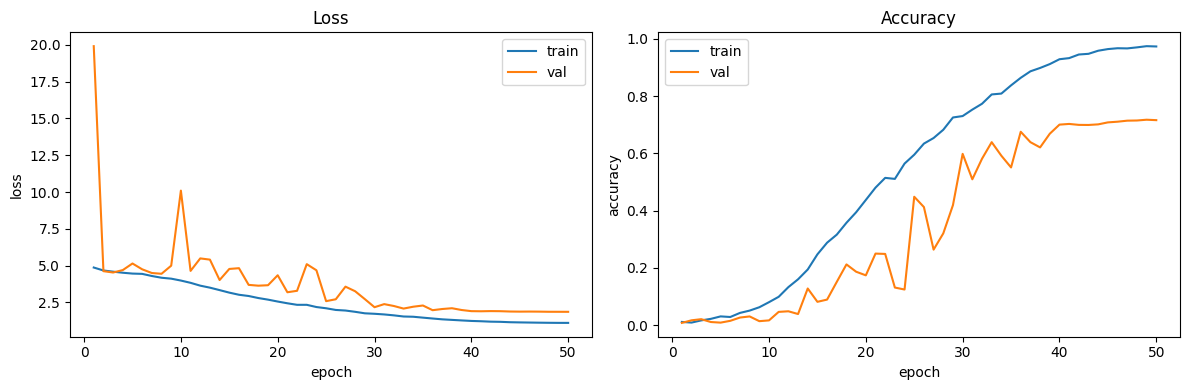

In [ ]:
config = TrainConfig(
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR",
    label_smoothing=0.1,
)

resnet = build_resnet()
trainset,valset,testset = get_datasets(split_validation=False)
model, history, losses, accuracies = run_experiment(
    resnet,
    config,
    50,
    trainset,
    valset,
    testset,
    name='base-resnet'
)
plot_results(history)

Total parameters: 11,227,812
epoch 1/50 loss=4.9932 accuracy=0.0108 val_loss=24.5727 val_accuracy=0.0072 time=79.7s eta=65.1min
epoch 2/50 loss=4.7305 accuracy=0.0102 val_loss=11.3074 val_accuracy=0.0132 time=77.5s eta=62.9min
epoch 3/50 loss=4.6975 accuracy=0.0093 val_loss=4.7333 val_accuracy=0.0147 time=77.7s eta=61.3min
epoch 4/50 loss=4.6335 accuracy=0.0117 val_loss=4.6436 val_accuracy=0.0180 time=81.2s eta=60.6min
epoch 5/50 loss=4.5503 accuracy=0.0240 val_loss=4.5334 val_accuracy=0.0249 time=85.5s eta=60.2min
epoch 6/50 loss=4.4935 accuracy=0.0240 val_loss=4.4892 val_accuracy=0.0261 time=81.8s eta=59.1min
epoch 7/50 loss=4.4938 accuracy=0.0258 val_loss=4.5166 val_accuracy=0.0234 time=83.4s eta=58.0min
epoch 8/50 loss=4.4716 accuracy=0.0264 val_loss=7.8534 val_accuracy=0.0117 time=84.8s eta=57.0min
epoch 9/50 loss=4.5150 accuracy=0.0240 val_loss=4.6942 val_accuracy=0.0144 time=84.2s eta=55.9min
epoch 10/50 loss=4.4586 accuracy=0.0255 val_loss=4.5155 val_accuracy=0.0318 time=85.5s 

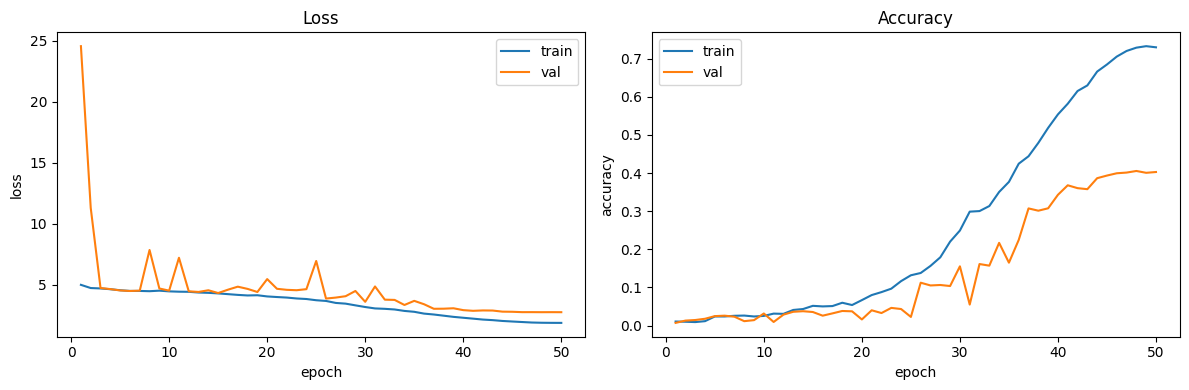

In [27]:
config = TrainConfig(
    learning_rate=0.005,
    weight_decay=1e-4,
    scheduler="CosineAnnealingLR",
    label_smoothing=0.1,
)

resnet = build_resnet()
trainset,valset,testset = get_datasets(split_validation=True)
model, history, losses, accuracies = run_experiment(
    resnet,
    config,
    50,
    trainset,
    valset,
    testset,
    name='base-resnet'
)
plot_results(history)

### Final implementation

In [35]:
def mixup_criterion(criterion, preds, y_a, y_b, lam):
    return lam * criterion(preds, y_a) + (1 - lam) * criterion(preds, y_b)

def mixup_data(x, y, alpha=0.2, device='cuda'):
    if alpha <= 0: return x, y, None, None, 1.0
    lam = torch.distributions.Beta(alpha, alpha).sample().item()
    batch_size = x.size()[0]
    if batch_size == 1: return x, y, None, None, 1.0
    index = torch.randperm(batch_size).to(device)
    mixed_x = lam * x + (1 - lam) * x[index, :]
    y_a, y_b = y, y[index]
    return mixed_x, y_a, y_b, index, lam

def plot_training_history(training_dict,title_suffix =''):
    plt.figure(figsize=(10,8))
    plt.plot(training_dict['train_loss'],label = 'Training_loss')
    plt.plot(training_dict['val_loss'],label = 'Validation_loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'Training vs  Validation Loss {title_suffix}')
    plt.legend()
    plt.show()

    #Validation accuracy plot
    plt.figure(figsize= (10,8))
    plt.plot(training_dict['val_acc'],label= 'Validation accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy %')
    plt.title(f'Validation accuracy over epochs {title_suffix}')
    plt.legend()
    plt.show()

def accuracy_score(output,target):
    preds = output.argmax(dim=1)
    return (preds==target).sum().item()




def train_model(model,train_dataset,val_dataset,
                checkpoint_path,
                device=None,
                optimizer_type='adam',
                scheduler_type='ReduceLROnPlateau',
                lr_backbone=None,
                lr_head=None,
                num_epochs=100,
                early_stop_patience=10,
                mixup_alpha=0.0,
                steps_per_epoch=None,
                title_suffix=""):

    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)

    model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

    # Optimizer setup
    if optimizer_type.lower() == 'adam':
        optimizer = Adam(model.parameters(), lr=1e-4,weight_decay=1e-4,decoupled_weight_decay = True)
    elif optimizer_type.lower() == 'sgd':
         optimizer = SGD([
    {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': lr_backbone},
    {'params': model.fc.parameters(), 'lr': lr_head}], momentum=0.9, weight_decay=1e-4)
    else:
        print("The optimizer must be Adam or SGD")
    # Scheduler
    if scheduler_type == 'ReduceLROnPlateau':
        scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=3)
    elif scheduler_type == 'OneCycleLR':
      if steps_per_epoch is None:
            steps_per_epoch = math.ceil(len(train_loader))
      scheduler = OneCycleLR(optimizer, max_lr=[lr_backbone, lr_head],
                               total_steps=steps_per_epoch*num_epochs,
                               pct_start=0.3, div_factor=10, final_div_factor=10000, epochs=num_epochs)
    else:
      scheduler = None

    # Training loop

    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    best_val_acc = 0
    no_improve_epochs = 0
    for epoch in range(1, num_epochs+1):
        model.train()
        running_loss, running_correct, running_total = 0, 0, 0

        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if mixup_alpha > 0:
                imgs, y_a, y_b, _, lam = mixup_data(imgs, labels, alpha=mixup_alpha, device=device)
            else:
                y_a, y_b, lam = labels, None, 1.0

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam) if mixup_alpha > 0 else criterion(outputs, y_a)
            loss.backward()
            optimizer.step()
            if scheduler_type == 'OneCycleLR':
                scheduler.step()

            running_loss += loss.item() * imgs.size(0)
            running_correct += accuracy_score(outputs, y_a)
            running_total += imgs.size(0)

        train_loss = running_loss / running_total
        train_acc  = 100 * running_correct / running_total

        # Validation
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * imgs.size(0)
                val_correct += accuracy_score(outputs, labels)
                val_total += imgs.size(0)

        val_loss /= val_total
        val_acc = 100 * val_correct / val_total

        if scheduler_type == 'ReduceLROnPlateau':
            scheduler.step(val_acc)

        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            no_improve_epochs = 0
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict() if scheduler else None,
                'best_val_acc': best_val_acc,
                'history': history
            }, checkpoint_path)
            print(f"Epoch {epoch}: New best model saved with Val Acc = {best_val_acc:.2f}%")
        else:
            no_improve_epochs += 1

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch} | Train Loss {train_loss:.4f} | Train Acc {train_acc:.2f}% | "
              f"Val Loss {val_loss:.4f} | Val Acc {val_acc:.2f}%")

        if no_improve_epochs >= early_stop_patience:
            print(f"No improvement for {early_stop_patience} epochs. Early stopping.")
            break
    print(f"Training finished. Best val accuracy: {best_val_acc:.2f}%")
    print("Checkpoint saved at:", checkpoint_path)
    plot_training_history(history, title_suffix=title_suffix)
    return history, best_val_acc


Dataset complete, skip download!
Training samples: 3334
Test samples: 3333
Classes: 100

Analysis of the first sample:
 - Dimension of the image tensor: torch.Size([3, 224, 224]) (Channels, Heigth, Length)
 - Index of the label: 0
 - Name of the variant: 707-320


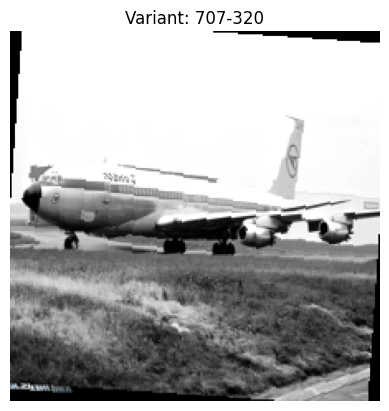

In [38]:
import shutil, os

test_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Training T for Phase 1
train_transform = T.Compose([
    T.Resize((224, 224)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

data_dir = "./data"
# Checks dataset is complete
variants_exists = os.path.exists(os.path.join(data_dir, 'fgvc-aircraft-2013b/data/variants.txt'))

if variants_exists:
    print("Dataset complete, skip download!")
    download_flag = False
else:
    print("Dataset incomplete or missing, re-download!")
    if os.path.exists(data_dir):
        shutil.rmtree(data_dir)
    download_flag = True

# Train
train_dataset = FGVCAircraft(
    root=data_dir,
    split='train',
    annotation_level='variant',
    download=download_flag,
    transform=train_transform
)

# Validation
val_dataset = FGVCAircraft(
    root=data_dir,
    split='val',
    annotation_level='variant',
    download=download_flag,
    transform=val_transform
)

# Test
test_dataset = FGVCAircraft(
    root=data_dir,
    split='test',
    annotation_level='variant',
    download=download_flag,
    transform=test_transform
)

print(f"Training samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {len(train_dataset.classes)}")

image, label_idx = train_dataset[0]
class_name = train_dataset.classes[label_idx]
print(f"\nAnalysis of the first sample:")
print(f" - Dimension of the image tensor: {image.shape} (Channels, Heigth, Length)")
print(f" - Index of the label: {label_idx}")
print(f" - Name of the variant: {class_name}")

# ToTensor() converts the images in the format [C, H, W],
# but matplotlib wants images in this format [H, W, C], so I use permute()
mean = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
std = torch.tensor([0.5, 0.5, 0.5]).view(3, 1, 1)
image_vis = image * std + mean          # un-normalize
image_vis = torch.clamp(image_vis, 0, 1) # clamp
image_vis = image_vis.permute(1, 2, 0)   # permute
plt.imshow(image_vis)                    # ✅ no warning!
plt.title(f"Variant: {class_name}")
plt.axis('off')
plt.show()

Using device: cuda
Epoch 1: New best model saved with Val Acc = 1.11%
Epoch 1 | Train Loss 4.7539 | Train Acc 0.84% | Val Loss 4.6787 | Val Acc 1.11%
Epoch 2: New best model saved with Val Acc = 1.47%
Epoch 2 | Train Loss 4.6484 | Train Acc 1.23% | Val Loss 4.6322 | Val Acc 1.47%
Epoch 3: New best model saved with Val Acc = 2.04%
Epoch 3 | Train Loss 4.6050 | Train Acc 1.50% | Val Loss 4.6018 | Val Acc 2.04%
Epoch 4: New best model saved with Val Acc = 2.40%
Epoch 4 | Train Loss 4.5686 | Train Acc 2.25% | Val Loss 4.5671 | Val Acc 2.40%
Epoch 5: New best model saved with Val Acc = 3.54%
Epoch 5 | Train Loss 4.5430 | Train Acc 2.16% | Val Loss 4.5307 | Val Acc 3.54%
Epoch 6: New best model saved with Val Acc = 4.23%
Epoch 6 | Train Loss 4.4987 | Train Acc 2.28% | Val Loss 4.4933 | Val Acc 4.23%
Epoch 7: New best model saved with Val Acc = 5.16%
Epoch 7 | Train Loss 4.4564 | Train Acc 3.54% | Val Loss 4.4537 | Val Acc 5.16%
Epoch 8: New best model saved with Val Acc = 6.66%
Epoch 8 | Tra

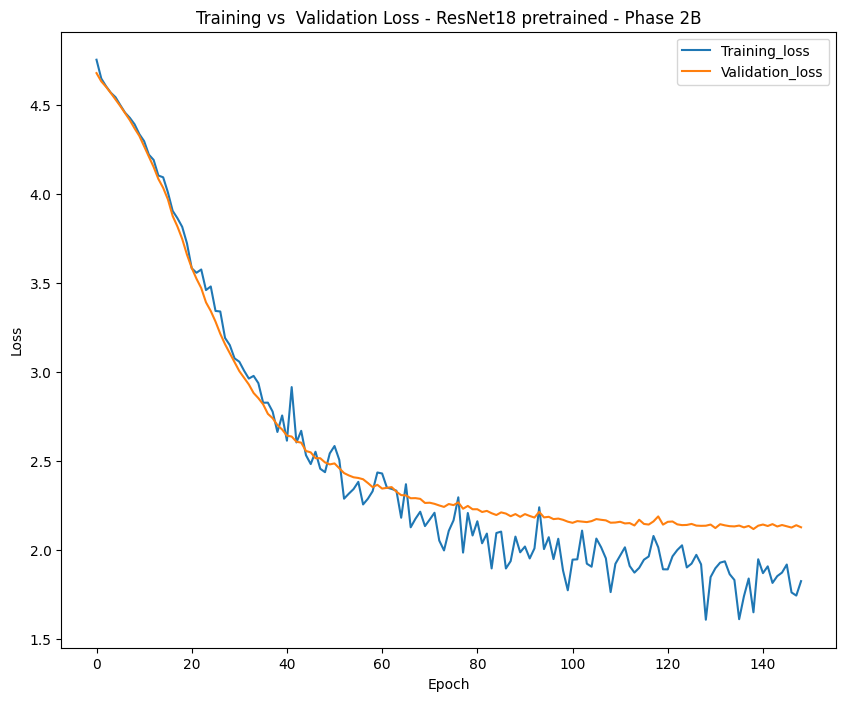

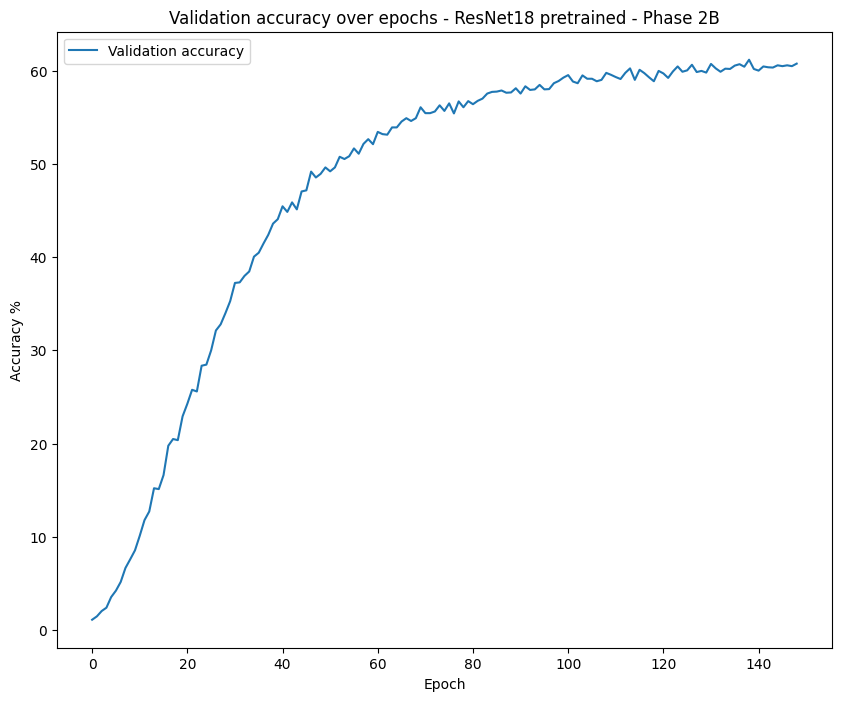

Evaluation on test set finished
Final loss: 1.5940958344110168
Final accuracy: 0.6183618361836184


In [39]:
resnet_checkpoint2 = Path('./weights') / "resnet_checkpoint2.pt"
train_dataset,val_dataset,testset = get_datasets(split_validation=True)
model = build_resnet()
history, best_val_acc = train_model(
    model=model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    checkpoint_path=resnet_checkpoint2,
    optimizer_type='sgd',
    scheduler_type='OneCycleLR',
    lr_backbone=3e-4,
    lr_head=3e-3,
    num_epochs=150,
    early_stop_patience=10,
    mixup_alpha=0.3,
    steps_per_epoch=math.ceil(len(train_dataset)/64),
    title_suffix="- ResNet18 pretrained - Phase 2B"
)


loss, accuracy = evaluate(
    model,
    testset,
    batch_size=BATCH_SIZE
)

print("Evaluation on test set finished")
print(f"Final loss: {loss}")
print(f"Final accuracy: {accuracy}")


In [ ]:
# TODO: tuning of the hyperparameters, given the baseline at the previous step

resnet = build_resnet()
model, losses, accuracies = train(
    model,
    loader,
    device=DEVICE,
    # training hyperparameters to tweak
    epochs=epochs,
    optimizer=optimizer,
    scheduler=scheduler,
    learning_rate=learning_rate
)